# Laboratorio 7 – Perfiles y salario de la población asalariada de la ENEIC con Spark

Este notebook estudia el salario mensual de la población asalariada de Guatemala con las bases de Personas de la Encuesta Nacional de Empleo e Ingresos Continua del Instituto Nacional de Estadística. Los cuatro trimestres de 2025 forman el conjunto de desarrollo y el primer trimestre de 2026 se prepara con las mismas reglas y se reserva para la evaluación final de los modelos supervisados.

Esta entrega cubre la sección de análisis exploratorio y segmentación. El Ejercicio 1 carga y armoniza los cinco archivos, documenta la procedencia de cada registro, mide los faltantes, aplica los filtros de la población analítica en un orden fijo, verifica la unicidad de la clave de registro y guarda los conjuntos preparados. El Ejercicio 2 describe el salario, la edad, la antigüedad y la jornada de los asalariados de 2025 y responde con evidencia gráfica cómo varía el salario entre grupos y trimestres. El Ejercicio 3 mide la asociación lineal entre las variables numéricas con Correlation.corr. El Ejercicio 4 segmenta a los asalariados con KMeans, evalúa si conviene incluir el salario, selecciona el número de grupos y describe cada perfil. Los resultados describen a los registros analizados, no son estimaciones oficiales de la población del país y las asociaciones encontradas no implican causalidad.

## Verificación de entorno

Se comprueba la versión de Python, el intérprete que ejecuta el cuaderno, la versión de Java sobre la que corre Spark, la disponibilidad de los paquetes requeridos y la existencia de los cinco archivos de datos y de sus cinco diccionarios. Cualquier ausencia se detecta aquí, antes de iniciar el análisis.

In [1]:
import importlib
import shutil
import subprocess
import sys
from pathlib import Path

print("Python    :", sys.version.split()[0])
print("Ejecutable:", sys.executable)

ruta_java = shutil.which("java")
if ruta_java is None:
    print("Java      : no encontrado en el PATH")
else:
    salida = subprocess.run([ruta_java, "-version"], capture_output=True, text=True)
    lineas = [l.strip() for l in (salida.stderr + salida.stdout).splitlines() if "version" in l.lower()]
    print("Java      :", lineas[0] if lineas else "version no identificada")

print("-" * 60)

PAQUETES = ["pyspark", "pandas", "numpy", "openpyxl", "matplotlib", "seaborn"]
for nombre in PAQUETES:
    try:
        modulo = importlib.import_module(nombre)
        print(f"{nombre:<11}", modulo.__version__)
    except ImportError:
        print(f"{nombre:<11}", "NO DISPONIBLE")

print("-" * 60)

# la raiz del proyecto es la carpeta que contiene a notebook
DIR_BASE = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
DIR_RAW = DIR_BASE / "data" / "raw"

ARCHIVOS_ESPERADOS = [
    "BaseDatos_Personas_ENEIC_I_2025.xlsx",
    "BaseDatos_Personas_ENEIC_II_2025.xlsx",
    "BaseDatos_Personas_ENEIC_III_2025.xlsx",
    "BaseDatos_Personas_ENEIC_IV_2025.xlsx",
    "BaseDatos_Personas_ENEIC_I_2026.xlsx",
    "Diccionario_Personas_ENEIC_I_2025.xlsx",
    "Diccionario_Personas_ENEIC_II_2025.xlsx",
    "Diccionario_Personas_ENEIC_III_2025.xlsx",
    "Diccionario_Personas_ENEIC_IV_2025.xlsx",
    "Diccionario_Personas_ENEIC_I_2026.xlsx",
]
for nombre in ARCHIVOS_ESPERADOS:
    ruta = DIR_RAW / nombre
    estado = f"{ruta.stat().st_size / 1e6:6.1f} MB" if ruta.exists() else "FALTANTE"
    print(f"{nombre:<42} {estado}")

Python    : 3.12.0
Ejecutable: c:\Users\andre\Desktop\Laboratorio7\.venv\Scripts\python.exe
Java      : java version "21.0.12" 2026-07-21 LTS
------------------------------------------------------------
pyspark     3.5.1
pandas      3.0.6
numpy       2.5.3
openpyxl    3.1.5
matplotlib  3.11.2
seaborn     0.13.2
------------------------------------------------------------
BaseDatos_Personas_ENEIC_I_2025.xlsx         47.7 MB
BaseDatos_Personas_ENEIC_II_2025.xlsx        16.9 MB
BaseDatos_Personas_ENEIC_III_2025.xlsx       47.6 MB
BaseDatos_Personas_ENEIC_IV_2025.xlsx        51.3 MB
BaseDatos_Personas_ENEIC_I_2026.xlsx         46.0 MB
Diccionario_Personas_ENEIC_I_2025.xlsx        0.1 MB
Diccionario_Personas_ENEIC_II_2025.xlsx       0.1 MB
Diccionario_Personas_ENEIC_III_2025.xlsx      0.1 MB
Diccionario_Personas_ENEIC_IV_2025.xlsx       0.1 MB
Diccionario_Personas_ENEIC_I_2026.xlsx        0.1 MB


## Configuración del proyecto

Las rutas se definen una sola vez y se reutilizan en todo el cuaderno. Los archivos originales permanecen sin cambios en data/raw, los conjuntos derivados se escriben en data/processed y las figuras en figures. Cada archivo de datos queda asociado con el corte publicado al que pertenece, que es la fuente de las columnas de procedencia, y con su diccionario de datos.

In [2]:
DIR_PROCESADO = DIR_BASE / "data" / "processed"
DIR_FIGURAS = DIR_BASE / "figures"
for carpeta in [DIR_PROCESADO, DIR_FIGURAS]:
    carpeta.mkdir(parents=True, exist_ok=True)

INDICE_FIGURAS = DIR_FIGURAS / "indice_figuras.csv"
RUTA_METADATOS = DIR_PROCESADO / "metadatos_archivos.json"
RUTA_ANALITICA_2025 = DIR_PROCESADO / "eneic_2025_analitica.parquet"
RUTA_ANALITICA_2026 = DIR_PROCESADO / "eneic_2026_analitica.parquet"

# cada archivo se identifica por el corte publicado y no por la columna TRIMESTRE
ARCHIVOS_ENEIC = {
    "2025T1": {"datos": "BaseDatos_Personas_ENEIC_I_2025.xlsx", "diccionario": "Diccionario_Personas_ENEIC_I_2025.xlsx", "anio": 2025, "trimestre": 1},
    "2025T2": {"datos": "BaseDatos_Personas_ENEIC_II_2025.xlsx", "diccionario": "Diccionario_Personas_ENEIC_II_2025.xlsx", "anio": 2025, "trimestre": 2},
    "2025T3": {"datos": "BaseDatos_Personas_ENEIC_III_2025.xlsx", "diccionario": "Diccionario_Personas_ENEIC_III_2025.xlsx", "anio": 2025, "trimestre": 3},
    "2025T4": {"datos": "BaseDatos_Personas_ENEIC_IV_2025.xlsx", "diccionario": "Diccionario_Personas_ENEIC_IV_2025.xlsx", "anio": 2025, "trimestre": 4},
    "2026T1": {"datos": "BaseDatos_Personas_ENEIC_I_2026.xlsx", "diccionario": "Diccionario_Personas_ENEIC_I_2026.xlsx", "anio": 2026, "trimestre": 1},
}
PERIODOS_2025 = ["2025T1", "2025T2", "2025T3", "2025T4"]
PERIODO_PRUEBA = "2026T1"

# cambiar a True obliga a releer las hojas de calculo aunque ya existan los Parquet
FORZAR_CONVERSION = False

SEMILLA = 42

for periodo, info in ARCHIVOS_ENEIC.items():
    print(f"{periodo}  {info['datos']:<40} {info['diccionario']}")

2025T1  BaseDatos_Personas_ENEIC_I_2025.xlsx     Diccionario_Personas_ENEIC_I_2025.xlsx
2025T2  BaseDatos_Personas_ENEIC_II_2025.xlsx    Diccionario_Personas_ENEIC_II_2025.xlsx
2025T3  BaseDatos_Personas_ENEIC_III_2025.xlsx   Diccionario_Personas_ENEIC_III_2025.xlsx
2025T4  BaseDatos_Personas_ENEIC_IV_2025.xlsx    Diccionario_Personas_ENEIC_IV_2025.xlsx
2026T1  BaseDatos_Personas_ENEIC_I_2026.xlsx     Diccionario_Personas_ENEIC_I_2026.xlsx


### Utilidades de figuras y estilo gráfico

Las figuras se guardan con un contador secuencial que produce sus nombres sucesivamente, y registra número, archivo y descripción en indice_figuras.csv. El índice se reinicia en cada ejecución completa. Se fija una paleta única para todo el cuaderno, un azul para magnitudes, un naranja para la serie de contraste y un gris para las líneas de referencia, junto con un orden fijo de colores para los grupos.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

COLOR_PRINCIPAL = "#2a78d6"
COLOR_CONTRASTE = "#eb6834"
COLOR_REFERENCIA = "#52514e"
PALETA_GRUPOS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e5e0", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

if INDICE_FIGURAS.exists():
    INDICE_FIGURAS.unlink()
CONTADOR_FIGURAS = {"n": 0}


def guardar_figura(descripcion):
    """Guarda la figura activa con numeracion secuencial y la registra en el indice."""
    CONTADOR_FIGURAS["n"] += 1
    nombre = f"Figura{CONTADOR_FIGURAS['n']}.png"
    plt.savefig(DIR_FIGURAS / nombre, dpi=150, bbox_inches="tight")
    registro = pd.DataFrame([{"numero": CONTADOR_FIGURAS["n"], "archivo": nombre, "descripcion": descripcion}])
    registro.to_csv(INDICE_FIGURAS, mode="a", header=not INDICE_FIGURAS.exists(), index=False, encoding="utf-8")
    return nombre


print("Utilidades de figuras listas")

Utilidades de figuras listas


### Sesión de Spark

Se crea una sesión local con todos los hilos disponibles. La conversión con Arrow queda desactivada porque exige permisos adicionales y aquí solo se trasladan a pandas tablas agregadas y muestras pequeñas, donde no ofrece ventaja apreciable.

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

spark = (
    SparkSession.builder
    .appName("Laboratorio7_ENEIC")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)
print("Java :", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))
print("Hilos:", spark.sparkContext.defaultParallelism)

Spark: 3.5.1
Java : 21.0.12
Hilos: 8


## Ejercicio 1 – Carga, armonización y calidad de los datos

Este ejercicio construye la base analítica del laboratorio. Primero se leen los diccionarios de datos para obtener las etiquetas oficiales y validar los códigos. Después se examina la estructura de cada archivo, se leen únicamente las columnas requeridas, se homologan sus tipos y se agregan las columnas de procedencia. Los cuatro archivos de 2025 se apilan con unionByName, se miden los valores faltantes antes de filtrar, se aplican los criterios de la población analítica en un orden fijo contando las exclusiones de cada paso y se verifica que la combinación de periodo de archivo, hogar y persona sea única. Los conjuntos preparados de 2025 y 2026 se guardan por separado en Parquet.

### 1.1 – Variables seleccionadas y diccionario de códigos

Se declara la correspondencia entre cada columna original y su nombre analítico. Las etiquetas de nivel educativo, categoría ocupacional y dominio se extraen de la sección de valores de cada diccionario, y se comprueba que los cinco diccionarios asignen exactamente las mismas etiquetas a los mismos códigos. Si coinciden, un único catálogo sirve para validar los códigos de todos los archivos.

In [5]:
MAPA_COLUMNAS = {
    "P05D01": "salario_mensual",
    "P02A03": "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16": "categoria_ocupacional",
    "DOMINIO": "dominio",
    "OCUPADOS": "ocupado",
}
COLUMNAS_AUDITORIA = ["NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE"]
COLUMNAS_ORIGEN = list(MAPA_COLUMNAS) + COLUMNAS_AUDITORIA

VARIABLES_NUMERICAS = ["salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "horas_semanales", "FACTOR"]
VARIABLES_CODIGO = ["nivel_educativo", "categoria_ocupacional", "dominio", "ocupado"]
VARIABLES_ENTERAS = ["NUM_HOGAR", "NUM_PERSONA", "ANIO", "TRIMESTRE"]

pd.DataFrame({"columna_original": list(MAPA_COLUMNAS) + COLUMNAS_AUDITORIA,
              "nombre_analitico": list(MAPA_COLUMNAS.values()) + COLUMNAS_AUDITORIA})

,columna_original,nombre_analitico
0,P05D01,salario_mensual
1,P02A03,edad
2,P05C07A,antiguedad_anios
3,P05C07B,antiguedad_meses
4,P05H01A,horas_semanales
5,P03A03A,nivel_educativo
6,P05C16,categoria_ocupacional
7,DOMINIO,dominio
8,OCUPADOS,ocupado
9,NUM_HOGAR,NUM_HOGAR


In [6]:
def leer_valores_diccionario(ruta):
    """Extrae la tabla de codigos y etiquetas de la seccion de valores de un diccionario."""
    hoja = pd.read_excel(ruta, header=None, dtype=str)
    inicio = hoja.index[hoja[0].astype(str).str.strip() == "Valores de variable"][0]
    valores = hoja.iloc[inicio + 2:, :3].copy()
    valores.columns = ["variable", "codigo", "etiqueta"]
    valores["variable"] = valores["variable"].ffill().str.strip()
    valores = valores.dropna(subset=["codigo"])
    valores["codigo"] = valores["codigo"].str.strip()
    valores["etiqueta"] = valores["etiqueta"].str.strip()
    return valores


def limpiar_etiqueta(texto):
    """Quita el signo de interrogacion final y normaliza mayusculas sostenidas."""
    texto = texto.strip().rstrip("?").strip()
    return texto.capitalize() if texto.isupper() else texto


VARIABLES_DICCIONARIO = {"P03A03A": "nivel_educativo", "P05C16": "categoria_ocupacional", "DOMINIO": "dominio", "OCUPADOS": "ocupado"}

catalogos = []
for periodo, info in ARCHIVOS_ENEIC.items():
    valores = leer_valores_diccionario(DIR_RAW / info["diccionario"])
    valores = valores[valores["variable"].isin(VARIABLES_DICCIONARIO)].assign(periodo_archivo=periodo)
    catalogos.append(valores)
catalogos = pd.concat(catalogos, ignore_index=True)

# un catalogo es consistente si cada codigo recibe la misma etiqueta en los cinco diccionarios
consistencia = catalogos.groupby(["variable", "codigo"]).agg(
    diccionarios=("periodo_archivo", "nunique"), etiquetas_distintas=("etiqueta", "nunique")
)
print("Codigos revisados:", len(consistencia))
print("Codigos presentes en los cinco diccionarios:", int((consistencia["diccionarios"] == 5).sum()))
print("Codigos con etiquetas distintas entre diccionarios:", int((consistencia["etiquetas_distintas"] > 1).sum()))

Codigos revisados: 21
Codigos presentes en los cinco diccionarios: 21
Codigos con etiquetas distintas entre diccionarios: 0


In [7]:
catalogo = catalogos[catalogos["periodo_archivo"] == "2025T1"].copy()
catalogo["etiqueta"] = catalogo["etiqueta"].map(limpiar_etiqueta)

ETIQUETAS = {
    VARIABLES_DICCIONARIO[variable]: dict(zip(grupo["codigo"], grupo["etiqueta"]))
    for variable, grupo in catalogo.groupby("variable")
}
CATEGORIAS_ASALARIADAS = ["1", "2", "3", "4"]
ETIQUETA_DESCONOCIDA = "DESCONOCIDO"

# orden natural de las categorias para tablas y figuras
ORDEN_EDUCATIVO = [ETIQUETAS["nivel_educativo"][c] for c in sorted(ETIQUETAS["nivel_educativo"], key=int)]
ORDEN_OCUPACIONAL = [ETIQUETAS["categoria_ocupacional"][c] for c in CATEGORIAS_ASALARIADAS]
ORDEN_DOMINIO = [ETIQUETAS["dominio"][c] for c in sorted(ETIQUETAS["dominio"], key=int)]

for variable, etiquetas in ETIQUETAS.items():
    print(variable)
    for codigo, etiqueta in etiquetas.items():
        print(f"  {codigo:<3} {etiqueta}")
    print("-" * 60)

dominio
  1   Urbano Metropolitano
  2   Resto Urbano
  3   Rural Nacional
------------------------------------------------------------
ocupado
  1   Población ocupada
------------------------------------------------------------
nivel_educativo
  0   Ninguno
  1   Preprimaria
  2   Primaria
  3   Básico
  4   Diversificado
  5   Superior
  6   Maestría
  7   Doctorado
------------------------------------------------------------
categoria_ocupacional
  1   Empleado de gobierno
  2   Empleado de empresa privada
  3   Empleado jornalero o peón
  4   Del servicio doméstico
  5   Trabajador por cuenta propia NO agrícola
  6   Patrón empleador (a) socio (a) NO agrícola
  7   Trabajador por cuenta propia agrícola
  8   Patrón empleador (a) socio (a) agrícola
  9   Trabajador No remunerado
------------------------------------------------------------


### 1.2 – Lectura de las hojas de cálculo y esquema explícito

Se definen las funciones de lectura y normalización. La hoja se recorre en modo de solo lectura, se ubica cada variable requerida por su nombre en el encabezado y no por su posición, y se conservan únicamente las catorce columnas seleccionadas. Los valores numéricos se convierten a punto flotante, los códigos a texto sin decimales y los identificadores a enteros. El esquema de Spark se declara de forma explícita en lugar de inferirlo, para que todos los cortes compartan exactamente los mismos tipos.

In [8]:
import json
import math
from collections import Counter

import openpyxl


def leer_hoja(ruta):
    """Recorre la hoja en modo de solo lectura y devuelve el encabezado y las columnas requeridas."""
    libro = openpyxl.load_workbook(ruta, read_only=True, data_only=True)
    filas = libro.worksheets[0].iter_rows(values_only=True)
    encabezado = [str(c).strip().upper() if c is not None else "" for c in next(filas)]
    posiciones = [encabezado.index(c) for c in COLUMNAS_ORIGEN]
    registros = [tuple(fila[i] for i in posiciones) for fila in filas]
    libro.close()
    return encabezado, registros


def a_numero(valor):
    """Convierte un valor a flotante finito o a nulo si no es interpretable."""
    if valor is None or isinstance(valor, bool):
        return None
    try:
        numero = float(str(valor).strip().replace(",", ""))
    except ValueError:
        return None
    return numero if math.isfinite(numero) else None


def a_codigo(valor):
    """Normaliza un codigo a texto sin decimales, sin importar si llego como numero o como texto."""
    numero = a_numero(valor)
    if numero is not None and numero.is_integer():
        return str(int(numero))
    if valor is None or str(valor).strip() == "":
        return None
    return str(valor).strip().upper()


def a_entero(valor):
    numero = a_numero(valor)
    return int(numero) if numero is not None and numero.is_integer() else None


ESQUEMA = T.StructType(
    [T.StructField(c, T.DoubleType()) for c in VARIABLES_NUMERICAS]
    + [T.StructField(c, T.StringType()) for c in VARIABLES_CODIGO]
    + [T.StructField(c, T.LongType()) for c in VARIABLES_ENTERAS]
    + [T.StructField("periodo_archivo", T.StringType()),
       T.StructField("anio_archivo", T.IntegerType()),
       T.StructField("trimestre_calendario", T.IntegerType()),
       T.StructField("archivo_origen", T.StringType())]
)
ORDEN_ESQUEMA = [campo.name for campo in ESQUEMA.fields]
print("Esquema explicito con", len(ORDEN_ESQUEMA), "columnas")

Esquema explicito con 18 columnas


### 1.3 – Conversión individual a Parquet y estructura de los archivos

Cada archivo se procesa por separado para acotar el uso de memoria. Se recorre la hoja en modo de solo lectura conservando las catorce columnas requeridas, se registra el tipo con el que llegó cada una, se normalizan los valores y se construye un DataFrame de Spark con el esquema explícito anterior. Los códigos se guardan como texto sin decimales, de modo que un 2 numérico y un 2 textual resultan idénticos. Las columnas periodo_archivo, anio_archivo, trimestre_calendario y archivo_origen se asignan desde el archivo leído y no desde TRIMESTRE, que se conserva intacta. Del mismo recorrido se guardan el encabezado completo y los tipos detectados, lo que permite comparar la estructura de los cortes sin volver a abrir las hojas. Si los Parquet y los metadatos ya existen, se reutilizan en lugar de releer las hojas de cálculo.

In [9]:
def ruta_parquet_crudo(periodo):
    return DIR_PROCESADO / f"eneic_{periodo}_seleccion.parquet"


def convertir_archivo(periodo):
    """Lee un archivo original, homologa tipos, lo escribe en Parquet y devuelve sus metadatos."""
    info = ARCHIVOS_ENEIC[periodo]
    encabezado, registros = leer_hoja(DIR_RAW / info["datos"])

    tipos = {}
    for j, columna in enumerate(COLUMNAS_ORIGEN):
        conteo = Counter(type(r[j]).__name__ for r in registros if r[j] is not None)
        tipos[columna] = " y ".join(sorted(conteo)) if conteo else "vacia"

    filas = []
    for r in registros:
        valor = dict(zip(COLUMNAS_ORIGEN, r))
        fila = {MAPA_COLUMNAS.get(k, k): v for k, v in valor.items()}
        filas.append(
            tuple(a_numero(fila[c]) for c in VARIABLES_NUMERICAS)
            + tuple(a_codigo(fila[c]) for c in VARIABLES_CODIGO)
            + tuple(a_entero(fila[c]) for c in VARIABLES_ENTERAS)
            + (periodo, info["anio"], info["trimestre"], info["datos"])
        )
    spark.createDataFrame(filas, schema=ESQUEMA).write.mode("overwrite").parquet(str(ruta_parquet_crudo(periodo)))

    return {
        "periodo_archivo": periodo,
        "archivo_origen": info["datos"],
        "filas_originales": len(registros),
        "columnas_originales": len(encabezado),
        "encabezado": encabezado,
        "tipos_detectados": tipos,
    }


completos = RUTA_METADATOS.exists() and all(ruta_parquet_crudo(p).exists() for p in ARCHIVOS_ENEIC)
if completos and not FORZAR_CONVERSION:
    METADATOS = json.loads(RUTA_METADATOS.read_text(encoding="utf-8"))
    print("Se reutilizan los Parquet existentes")
else:
    METADATOS = {}
    for periodo in ARCHIVOS_ENEIC:
        METADATOS[periodo] = convertir_archivo(periodo)
        print(f"{periodo} convertido, {METADATOS[periodo]['filas_originales']} filas")
    RUTA_METADATOS.write_text(json.dumps(METADATOS, ensure_ascii=False, indent=1), encoding="utf-8")

pd.DataFrame([{k: v for k, v in m.items() if k not in {"encabezado", "tipos_detectados"}} for m in METADATOS.values()])

Se reutilizan los Parquet existentes


,periodo_archivo,archivo_origen,filas_originales,columnas_originales
0,2025T1,BaseDatos_Personas_ENEIC_I_2025.xlsx,51588,270
1,2025T2,BaseDatos_Personas-ENEIC-II-2025.xlsx,51167,270
2,2025T3,BaseDatos_Personas-ENEIC-III-2025.xlsx,51583,270
3,2025T4,BaseDatos_Personas-ENEIC-IV-2025.xlsx,49338,302
4,2026T1,BaseDatos_Personas-ENEIC-I-2026.xlsx,49843,270


In [10]:
# posicion de cada variable seleccionada dentro de cada archivo, contando desde 1
posiciones = pd.DataFrame(
    {p: {c: m["encabezado"].index(c) + 1 for c in COLUMNAS_ORIGEN} for p, m in METADATOS.items()}
)
posiciones.loc["TOTAL_COLUMNAS"] = [m["columnas_originales"] for m in METADATOS.values()]
display(posiciones)

referencia = METADATOS["2025T1"]["encabezado"]
for periodo, m in METADATOS.items():
    agregadas = [c for c in m["encabezado"] if c not in referencia]
    eliminadas = [c for c in referencia if c not in m["encabezado"]]
    mismo_orden = m["encabezado"] == referencia
    print(f"{periodo}: mismo encabezado que 2025T1 {mismo_orden}, agregadas {len(agregadas)}, eliminadas {len(eliminadas)}")
    if agregadas or eliminadas:
        print("  agregadas :", ", ".join(agregadas[:12]), "y otras" if len(agregadas) > 12 else "")
        print("  eliminadas:", ", ".join(eliminadas))

,2025T1,2025T2,2025T3,2025T4,2026T1
P05D01,105,105,105,98,105
P02A03,13,13,13,9,13
P05C07A,68,68,68,61,68
P05C07B,69,69,69,62,69
P05H01A,218,218,218,208,218
P03A03A,33,33,33,29,33
P05C16,88,88,88,81,88
DOMINIO,3,3,3,3,3
OCUPADOS,266,266,266,298,266
NUM_HOGAR,4,4,4,4,4


2025T1: mismo encabezado que 2025T1 True, agregadas 0, eliminadas 0
2025T2: mismo encabezado que 2025T1 True, agregadas 0, eliminadas 0
2025T3: mismo encabezado que 2025T1 True, agregadas 0, eliminadas 0
2025T4: mismo encabezado que 2025T1 False, agregadas 42, eliminadas 10
  agregadas : P07A01A, P07A01B, P07A01C, P07A02A, P07A02B, P07A02C, P07A03A, P07A03B, P07A03C, P07A04A, P07A04B, P07A04C y otras
  eliminadas: P02A01C, P02A01D, P02A01G, P02A01I, P05C01A, P05C02A, P05C04A, P05G01A, P05G02A, P05G04A
2026T1: mismo encabezado que 2025T1 True, agregadas 0, eliminadas 0


In [11]:
# tipo con el que llego cada columna seleccionada en cada archivo
pd.DataFrame({p: m["tipos_detectados"] for p, m in METADATOS.items()})

,2025T1,2025T2,2025T3,2025T4,2026T1
P05D01,int,int,int,int,int
P02A03,int,int,int,int,int
P05C07A,int,int,int,int,int
P05C07B,int,str,int,int,int
P05H01A,int,int,int,int,int
P03A03A,int,str,int,int,int
P05C16,int,str,int,int,int
DOMINIO,int,str,int,int,int
OCUPADOS,int,str,int,int,int
NUM_HOGAR,int,int,int,int,int


Los cinco diccionarios asignan las mismas etiquetas a los 21 códigos revisados, por lo que un único catálogo sirve para todos los cortes. La estructura de los datos, en cambio, no es homogénea. Los cortes I, II y III de 2025 y I de 2026 comparten un encabezado idéntico de 270 columnas, mientras que IV de 2025 trae 302 columnas: agrega 42 variables nuevas de las secciones P07 y P08 y elimina 10 que sí existen en los demás cortes. Como consecuencia, casi todas las variables seleccionadas cambian de posición en ese archivo, por ejemplo el salario P05D01 pasa de la columna 105 a la 98 y OCUPADOS de la 266 a la 298. Además, el corte II de 2025 entrega los códigos categóricos y el componente de meses como texto, mientras que los demás los entregan como enteros. Ambas diferencias quedan neutralizadas porque cada variable se ubica por nombre y se convierte a un tipo único antes de escribir el Parquet.

### 1.4 – Unión de los archivos de 2025 por nombre de columna

Los cuatro Parquet de 2025 se apilan con unionByName, que empareja las columnas por nombre. El archivo de 2026 se carga por separado y no se mezcla con el desarrollo. Se muestran el esquema resultante y cinco registros de las columnas seleccionadas.

In [12]:
def cargar_periodos(periodos):
    """Lee los Parquet de varios cortes y los apila por nombre de columna."""
    marcos = [spark.read.parquet(str(ruta_parquet_crudo(p))) for p in periodos]
    unido = marcos[0]
    for marco in marcos[1:]:
        unido = unido.unionByName(marco)
    return unido


base_2025 = cargar_periodos(PERIODOS_2025).persist()
base_2026 = cargar_periodos([PERIODO_PRUEBA]).persist()

print("Registros apilados de 2025:", base_2025.count())
print("Registros de 2026         :", base_2026.count())
print("-" * 60)
base_2025.printSchema()

Registros apilados de 2025: 203676
Registros de 2026         : 49843
------------------------------------------------------------
root
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- ocupado: string (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: long (nullable = true)
 |-- ANIO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)



In [13]:
base_2025.select(
    "periodo_archivo", "anio_archivo", "trimestre_calendario", "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA",
    "edad", "ocupado", "categoria_ocupacional", "salario_mensual", "horas_semanales", "nivel_educativo", "dominio", "FACTOR",
).show(5, truncate=False)

+---------------+------------+--------------------+----+---------+---------+-----------+----+-------+---------------------+---------------+---------------+---------------+-------+------+
|periodo_archivo|anio_archivo|trimestre_calendario|ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|edad|ocupado|categoria_ocupacional|salario_mensual|horas_semanales|nivel_educativo|dominio|FACTOR|
+---------------+------------+--------------------+----+---------+---------+-----------+----+-------+---------------------+---------------+---------------+---------------+-------+------+
|2025T1         |2025        |1                   |2025|2        |3299     |1          |84.0|NULL   |NULL                 |NULL           |NULL           |2              |2      |300.0 |
|2025T1         |2025        |1                   |2025|2        |3299     |2          |78.0|NULL   |NULL                 |NULL           |NULL           |2              |2      |300.0 |
|2025T1         |2025        |1                   |2025|2        

In [14]:
# valores originales de TRIMESTRE frente al corte publicado de cada archivo
(
    base_2025.unionByName(base_2026)
    .groupBy("periodo_archivo", "anio_archivo", "trimestre_calendario", "ANIO", "TRIMESTRE")
    .count()
    .orderBy("periodo_archivo", "TRIMESTRE")
    .show(truncate=False)
)

+---------------+------------+--------------------+----+---------+-----+
|periodo_archivo|anio_archivo|trimestre_calendario|ANIO|TRIMESTRE|count|
+---------------+------------+--------------------+----+---------+-----+
|2025T1         |2025        |1                   |2025|2        |51588|
|2025T2         |2025        |2                   |2025|2        |175  |
|2025T2         |2025        |2                   |2025|3        |50992|
|2025T3         |2025        |3                   |2025|4        |51583|
|2025T4         |2025        |4                   |2025|5        |49338|
|2026T1         |2026        |1                   |2026|6        |49843|
+---------------+------------+--------------------+----+---------+-----+



La columna TRIMESTRE no representa el trimestre calendario. En I de 2025 vale 2, en III de 2025 vale 4, en IV de 2025 vale 5 y en I de 2026 vale 6, de modo que se comporta como un número correlativo de levantamiento. El corte II de 2025 mezcla dos valores, 3 en 50,992 registros y 2 en 175. Restar uno de forma automática funcionaría para la mayoría de los registros pero asignaría esos 175 al primer trimestre aunque pertenecen al archivo publicado para el segundo, y produciría un trimestre 5 inexistente para 2026. Por eso la procedencia se toma del archivo, que es el corte publicado, y TRIMESTRE se conserva sin cambios para auditoría. La columna ANIO sí coincide con el año del archivo en todos los registros.

### 1.5 – Valores faltantes antes de aplicar los filtros

Se cuenta, para cada variable seleccionada, cuántos registros vienen vacíos o con un valor no interpretable, sobre la base completa de 2025 y sobre la de 2026. A continuación se contrasta la ausencia con la estructura del cuestionario para distinguir los vacíos que corresponden a preguntas que no aplican a la persona de las respuestas que faltan donde sí aplicaba.

In [15]:
VARIABLES_REVISADAS = VARIABLES_NUMERICAS[:-1] + VARIABLES_CODIGO + VARIABLES_ENTERAS + ["FACTOR"]


def tabla_faltantes(sdf):
    total = sdf.count()
    conteos = sdf.agg(*[F.sum(F.col(c).isNull().cast("int")).alias(c) for c in VARIABLES_REVISADAS]).first().asDict()
    return pd.DataFrame({"faltantes": conteos, "porcentaje": {c: round(100 * v / total, 2) for c, v in conteos.items()}})


faltantes = pd.concat(
    {"2025": tabla_faltantes(base_2025), "2026T1": tabla_faltantes(base_2026)}, axis=1
)
faltantes

2025               2026T1           
                      faltantes porcentaje faltantes porcentaje
salario_mensual          150651      73.97     36585      73.40
edad                          0       0.00         0       0.00
antiguedad_anios         115454      56.69     28109      56.40
antiguedad_meses         115454      56.69     28109      56.40
horas_semanales          115454      56.69     28109      56.40
nivel_educativo           26344      12.93      6011      12.06
categoria_ocupacional    115454      56.69     28109      56.40
dominio                       0       0.00         0       0.00
ocupado                  115454      56.69     28109      56.40
NUM_HOGAR                     0       0.00         0       0.00
NUM_PERSONA                   0       0.00         0       0.00
ANIO                          0       0.00         0       0.00
TRIMESTRE                     0       0.00         0       0.00
FACTOR                        0       0.00         0       0.00

In [16]:
# relacion entre la ausencia de cada variable y la estructura del cuestionario
print("Edad minima con nivel educativo registrado:",
      base_2025.filter(F.col("nivel_educativo").isNotNull()).agg(F.min("edad")).first()[0])
print("Edad maxima sin nivel educativo registrado:",
      base_2025.filter(F.col("nivel_educativo").isNull()).agg(F.max("edad")).first()[0])
print("Edad minima entre ocupados:",
      base_2025.filter(F.col("ocupado") == "1").agg(F.min("edad")).first()[0])
print("Codigos observados en ocupado:",
      [r[0] for r in base_2025.select("ocupado").distinct().orderBy("ocupado").collect()])
print("-" * 60)

# el salario solo existe para las categorias asalariadas
(
    base_2025.groupBy("categoria_ocupacional")
    .agg(F.count(F.lit(1)).alias("registros"),
         F.sum(F.col("salario_mensual").isNotNull().cast("int")).alias("con_salario"),
         F.sum(F.col("horas_semanales").isNotNull().cast("int")).alias("con_horas"))
    .orderBy(F.col("categoria_ocupacional").cast("int"))
    .show()
)

Edad minima con nivel educativo registrado: 7.0
Edad maxima sin nivel educativo registrado: 6.0
Edad minima entre ocupados: 15.0
Codigos observados en ocupado: [None, '1']
------------------------------------------------------------
+---------------------+---------+-----------+---------+
|categoria_ocupacional|registros|con_salario|con_horas|
+---------------------+---------+-----------+---------+
|                 NULL|   115454|          0|        0|
|                    1|     6575|       6575|     6575|
|                    2|    28702|      28702|    28702|
|                    3|    13842|      13842|    13842|
|                    4|     3906|       3906|     3906|
|                    5|    20951|          0|    20951|
|                    6|     2624|          0|     2624|
|                    7|     6746|          0|     6746|
|                    8|      418|          0|      418|
|                    9|     4458|          0|     4458|
+---------------------+---------+------

Los faltantes son muy altos antes de filtrar, pero casi todos son estructurales. En 2025 falta el salario en 150,651 registros, el 73.97%, y la categoría ocupacional, la condición de ocupado, la antigüedad y las horas en 115,454 registros, el 56.69%. Esos 115,454 vacíos coinciden exactamente en las cinco variables porque corresponden a personas que no están ocupadas, a quienes no se les formula la sección de empleo; de hecho OCUPADOS solo registra el código 1 y deja vacío al resto. El nivel educativo falta en 26,344 registros, el 12.93%, y todos son menores de 7 años, que es la edad desde la cual se pregunta. El salario aparece exactamente en los 53,025 registros de las categorías asalariadas 1 a 4 y en ninguno de las categorías 5 a 9, que son trabajadores por cuenta propia, patronos y no remunerados, mientras que las horas se registran para todos los ocupados. Dentro de la población asalariada no queda ninguna respuesta faltante. El corte de 2026 muestra proporciones prácticamente iguales.

### 1.6 – Construcción de variables y validación de códigos

La antigüedad en años se obtiene como antiguedad_anios más antiguedad_meses dividido entre doce. Cada código categórico se traduce con el catálogo del diccionario, y todo código ausente o que no figura en el catálogo se marca como DESCONOCIDO, sin convertirlo a cero, ya que en nivel educativo el cero significa ninguno. La misma función se aplica a 2025 y a 2026 para que ambos conjuntos compartan exactamente las mismas reglas.

In [17]:
def etiquetar(columna, etiquetas):
    """Asigna la etiqueta del diccionario y marca como DESCONOCIDO lo ausente o no reconocido."""
    expresion = F.when(F.col(columna).isNull(), F.lit(ETIQUETA_DESCONOCIDA))
    for codigo, etiqueta in etiquetas.items():
        expresion = expresion.when(F.col(columna) == codigo, F.lit(etiqueta))
    return expresion.otherwise(F.lit(ETIQUETA_DESCONOCIDA))


def preparar(sdf):
    return (
        sdf.withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0))
        .withColumn("nivel_educativo_etiqueta", etiquetar("nivel_educativo", ETIQUETAS["nivel_educativo"]))
        .withColumn("categoria_ocupacional_etiqueta", etiquetar("categoria_ocupacional", ETIQUETAS["categoria_ocupacional"]))
        .withColumn("dominio_etiqueta", etiquetar("dominio", ETIQUETAS["dominio"]))
    )


preparado_2025 = preparar(base_2025)
preparado_2026 = preparar(base_2026)

# codigos presentes en los datos que no figuran en el diccionario
for columna in ["nivel_educativo", "categoria_ocupacional", "dominio", "ocupado"]:
    validos = list(ETIQUETAS[columna])
    fuera = (
        preparado_2025.unionByName(preparado_2026)
        .filter(F.col(columna).isNotNull() & ~F.col(columna).isin(validos))
        .count()
    )
    print(f"{columna:<22} codigos validos {validos}, registros con codigo fuera del diccionario: {fuera}")

nivel_educativo        codigos validos ['0', '1', '2', '3', '4', '5', '6', '7'], registros con codigo fuera del diccionario: 0
categoria_ocupacional  codigos validos ['1', '2', '3', '4', '5', '6', '7', '8', '9'], registros con codigo fuera del diccionario: 0
dominio                codigos validos ['1', '2', '3'], registros con codigo fuera del diccionario: 0
ocupado                codigos validos ['1'], registros con codigo fuera del diccionario: 0


### 1.7 – Filtros secuenciales de la población analítica

Los criterios se aplican siempre en el mismo orden. Primero los que definen la población objetivo, es decir edad de 15 años o más, condición de ocupado y categoría asalariada; después el salario mensual positivo, que es la variable objetivo; y al final las reglas de consistencia de antigüedad y horas. Un registro que no permite evaluar un criterio porque el dato es nulo se excluye en ese paso y queda contabilizado. No se imputa el salario ni se descartan salarios por ser extremos.

In [18]:
PASOS_FILTRO = [
    ("Edad finita y mayor o igual a 15",
     F.col("edad").isNotNull() & ~F.isnan("edad") & (F.col("edad") >= 15)),
    ("Ocupado igual a 1",
     F.col("ocupado") == "1"),
    ("Categoría ocupacional asalariada 1, 2, 3 o 4",
     F.col("categoria_ocupacional").isin(CATEGORIAS_ASALARIADAS)),
    ("Salario mensual numerico, finito y mayor que cero",
     F.col("salario_mensual").isNotNull() & ~F.isnan("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("Antigüedad en años no negativa",
     F.col("antiguedad_anios").isNotNull() & ~F.isnan("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    ("Meses de antiguedad enteros entre 0 y 11",
     F.col("antiguedad_meses").isNotNull() & ~F.isnan("antiguedad_meses") & F.col("antiguedad_meses").between(0, 11)
     & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))),
    ("Antigüedad calculada menor o igual a la edad",
     F.col("antiguedad") <= F.col("edad")),
    ("Horas habituales mayores que 0 y hasta 168",
     F.col("horas_semanales").isNotNull() & ~F.isnan("horas_semanales")
     & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
]


def aplicar_filtros(sdf):
    """Aplica los criterios en orden y registra los excluidos de cada paso por archivo."""
    actual = sdf
    conteo = actual.groupBy("periodo_archivo").count().toPandas().set_index("periodo_archivo")["count"]
    bitacora = [{"paso": 0, "criterio": "Registros originales", **conteo.to_dict()}]
    for numero, (criterio, condicion) in enumerate(PASOS_FILTRO, start=1):
        actual = actual.filter(condicion)
        nuevo = actual.groupBy("periodo_archivo").count().toPandas().set_index("periodo_archivo")["count"]
        nuevo = nuevo.reindex(conteo.index, fill_value=0)
        bitacora.append({"paso": numero, "criterio": criterio, **(conteo - nuevo).to_dict()})
        conteo = nuevo
    return actual, pd.DataFrame(bitacora), conteo


analitica_2025, bitacora_2025, final_2025 = aplicar_filtros(preparado_2025)
analitica_2026, bitacora_2026, final_2026 = aplicar_filtros(preparado_2026)
analitica_2025 = analitica_2025.persist()
analitica_2026 = analitica_2026.persist()

bitacora = bitacora_2025.merge(bitacora_2026, on=["paso", "criterio"])
bitacora["total_2025"] = bitacora[PERIODOS_2025].sum(axis=1)
print("Registros excluidos en cada paso, la fila 0 muestra los registros originales")
bitacora

Registros excluidos en cada paso, la fila 0 muestra los registros originales


,paso,criterio,2025T1,2025T2,2025T3,2025T4,2026T1,total_2025
0,0,Registros originales,51588,51167,51583,49338,49843,203676
1,1,Edad finita y mayor o igual a 15,16253,15882,15767,14984,14803,62886
2,2,Ocupado igual a 1,13062,12942,13443,13121,13306,52568
3,3,"Categoría ocupacional asalariada 1, 2, 3 o 4",8854,8851,8923,8569,8476,35197
4,4,"Salario mensual numerico, finito y mayor que cero",0,0,0,0,0,0
5,5,Antigüedad en años no negativa,0,0,0,0,0,0
6,6,Meses de antiguedad enteros entre 0 y 11,0,0,0,0,0,0
7,7,Antigüedad calculada menor o igual a la edad,0,0,0,0,0,0
8,8,Horas habituales mayores que 0 y hasta 168,0,0,0,0,0,0


In [19]:
# registros por archivo antes y despues de los filtros
por_archivo = pd.DataFrame({
    "antes_de_filtros": bitacora.loc[0, PERIODOS_2025 + [PERIODO_PRUEBA]],
    "despues_de_filtros": pd.concat([final_2025, final_2026]),
})
por_archivo["retenidos_porcentaje"] = (100 * por_archivo["despues_de_filtros"] / por_archivo["antes_de_filtros"]).round(2)
por_archivo.loc["Total 2025"] = por_archivo.loc[PERIODOS_2025].sum()
por_archivo.loc["Total 2025", "retenidos_porcentaje"] = round(
    100 * por_archivo.loc["Total 2025", "despues_de_filtros"] / por_archivo.loc["Total 2025", "antes_de_filtros"], 2
)
por_archivo

,antes_de_filtros,despues_de_filtros,retenidos_porcentaje
2025T1,51588.0,13419.0,26.01
2025T2,51167.0,13492.0,26.37
2025T3,51583.0,13450.0,26.07
2025T4,49338.0,12664.0,25.67
2026T1,49843.0,13258.0,26.60
Total 2025,203676.0,53025.0,26.03


Solo los tres primeros criterios eliminan registros. De los 203,676 registros de 2025, la condición de edad excluye 62,886 menores de 15 años, la de ocupación excluye 52,568 personas que no están ocupadas y la de categoría asalariada excluye 35,197 ocupados por cuenta propia, patronos o no remunerados, lo que deja 53,025 registros, el 26.03% del total. Los cinco criterios siguientes no excluyen ningún registro: todos los asalariados tienen un salario positivo, una antigüedad no negativa con meses enteros entre 0 y 11, una antigüedad menor o igual a su edad y una jornada entre 1 y 126 horas. Esto indica que la base publicada ya viene validada en esas reglas; aun así los criterios se mantienen para que la preparación sea reproducible sobre cortes futuros. La retención es estable entre archivos, de 25.67% en IV de 2025 a 26.60% en I de 2026, que queda con 13,258 registros para la prueba final.

### 1.8 – Unicidad de la clave de registro y estructura del panel

Se verifica que la combinación de periodo_archivo, NUM_HOGAR y NUM_PERSONA identifique un único registro dentro de cada corte. Si aparecieran claves repetidas, se distinguiría entre repeticiones exactas y registros en conflicto sin recurrir a dropDuplicates. Además se cuantifica cuántas combinaciones de hogar y persona aparecen en más de un corte, y se revisa que la edad registrada en esas apariciones sea coherente con el paso del tiempo, lo que respalda que se trata de la misma persona observada en varios trimestres.

In [20]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]


def revisar_unicidad(sdf, etiqueta):
    """Cuenta claves repetidas y separa repeticiones exactas de registros en conflicto."""
    columnas = [c for c in sdf.columns if c not in CLAVE]
    grupos = sdf.groupBy(*CLAVE).agg(
        F.count(F.lit(1)).alias("n"),
        F.countDistinct(F.struct(*columnas)).alias("versiones"),
    ).filter(F.col("n") > 1)
    resumen = grupos.agg(
        F.count(F.lit(1)).alias("claves_repetidas"),
        F.sum("n").alias("registros_involucrados"),
        F.sum((F.col("versiones") == 1).cast("int")).alias("repeticiones_exactas"),
        F.sum((F.col("versiones") > 1).cast("int")).alias("claves_en_conflicto"),
    ).first().asDict()
    return {"conjunto": etiqueta, "registros": sdf.count(), **{k: (v or 0) for k, v in resumen.items()}}


pd.DataFrame([
    revisar_unicidad(base_2025, "2025 antes de filtros"),
    revisar_unicidad(analitica_2025, "2025 población analítica"),
    revisar_unicidad(base_2026, "2026T1 antes de filtros"),
    revisar_unicidad(analitica_2026, "2026T1 población analítica"),
])

,conjunto,registros,claves_repetidas,registros_involucrados,repeticiones_exactas,claves_en_conflicto
0,2025 antes de filtros,203676,0,0,0,0
1,2025 población analítica,53025,0,0,0,0
2,2026T1 antes de filtros,49843,0,0,0,0
3,2026T1 población analítica,13258,0,0,0,0


In [21]:
# apariciones de cada combinacion de hogar y persona en los cortes de 2025
panel = analitica_2025.groupBy("NUM_HOGAR", "NUM_PERSONA").agg(
    F.countDistinct("periodo_archivo").alias("cortes"),
    (F.max("edad") - F.min("edad")).alias("variacion_edad"),
)
(
    panel.groupBy("cortes")
    .agg(F.count(F.lit(1)).alias("personas"), F.sum("cortes").alias("registros"))
    .orderBy("cortes")
    .show()
)

print("Variacion de edad entre la primera y la ultima aparicion, personas con mas de un corte")
panel.filter(F.col("cortes") > 1).groupBy("variacion_edad").count().orderBy("variacion_edad").show()

+------+--------+---------+
|cortes|personas|registros|
+------+--------+---------+
|     1|   11303|    11303|
|     2|    7831|    15662|
|     3|    4240|    12720|
|     4|    3335|    13340|
+------+--------+---------+

Variacion de edad entre la primera y la ultima aparicion, personas con mas de un corte
+--------------+-----+
|variacion_edad|count|
+--------------+-----+
|           0.0| 8730|
|           1.0| 6611|
|           2.0|   35|
|           3.0|    5|
|           4.0|    6|
|           5.0|    1|
|           6.0|    2|
|           7.0|    1|
|           8.0|    1|
|           9.0|    1|
|          10.0|    2|
|          11.0|    5|
|          14.0|    1|
|          16.0|    1|
|          19.0|    1|
|          23.0|    1|
|          25.0|    2|
+--------------+-----+



No existe ninguna clave repetida: la combinación de periodo, hogar y persona es única en los cuatro conjuntos revisados, por lo que no hay repeticiones exactas ni registros en conflicto que investigar. Entre cortes la situación es distinta. De las 26,709 combinaciones de hogar y persona de la población analítica de 2025, 11,303 aparecen en un solo corte, 7,831 en dos, 4,240 en tres y 3,335 en los cuatro. En otras palabras, 15,406 personas aportan 41,722 de los 53,025 registros, el 78.7%. En 15,341 de esas 15,406 personas, el 99.6%, la edad cambia cero o un año entre la primera y la última aparición, como corresponde a observar a la misma persona a lo largo de un año; las 65 restantes presentan saltos mayores que sugieren un cambio de informante o un error de captura. Esto confirma el diseño longitudinal con rotación y que el número de filas no equivale al número de personas.

### 1.9 – Almacenamiento de los conjuntos preparados

La población analítica de 2025 y la de 2026 se escriben en Parquet por separado. El conjunto de 2025 alimenta la exploración, la segmentación y el entrenamiento, y el de 2026 queda reservado para la evaluación final.

In [22]:
analitica_2025.write.mode("overwrite").parquet(str(RUTA_ANALITICA_2025))
analitica_2026.write.mode("overwrite").parquet(str(RUTA_ANALITICA_2026))

for ruta in [RUTA_ANALITICA_2025, RUTA_ANALITICA_2026]:
    guardado = spark.read.parquet(str(ruta))
    print(f"{ruta.name:<32} {guardado.count():>6} registros, {len(guardado.columns)} columnas")

eneic_2025_analitica.parquet      53025 registros, 22 columnas
eneic_2026_analitica.parquet      13258 registros, 22 columnas


### 1.10 – Respuestas del Ejercicio 1

Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos. Porque su estructura es distinta: tiene 302 columnas frente a 270, incorpora 42 variables que los demás cortes no tienen y omite 10 que sí tienen. Al cambiar el número y el orden de las columnas, la misma posición deja de corresponder a la misma variable; el salario, por ejemplo, está en la columna 105 de los demás archivos y en la 98 de este. Un apilamiento por posición mezclaría silenciosamente el salario con otra pregunta, sin producir ningún error visible. unionByName empareja las columnas por nombre, que es el identificador estable entre cortes.

Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada. El primero es un vacío estructural: el cuestionario aplica saltos de pase y la pregunta nunca se formula a esa persona, como ocurre con el salario de quien trabaja por cuenta propia o con el nivel educativo de un niño de 5 años. Ese vacío es la respuesta correcta y se resuelve delimitando bien la población analítica, no imputando. El segundo es una no respuesta: la pregunta sí correspondía pero no quedó registrada, por rechazo, desconocimiento o error de captura, y representa información perdida que puede sesgar los resultados si no ocurre al azar. En estas bases la sección anterior muestra que prácticamente todos los faltantes son del primer tipo, ya que dentro de la población asalariada no queda ningún valor ausente.

Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal. Porque la unidad de observación es la persona en un período, no la persona. La encuesta vuelve a entrevistar a los mismos hogares en trimestres sucesivos, y cada visita es una medición legítima en un momento distinto, en la que pueden haber cambiado el salario, la jornada o la antigüedad. En los datos, 15,406 personas aparecen en más de un corte y aportan el 78.7% de los registros; eliminarlas como duplicados descartaría información válida y sesgaría la base hacia quienes solo aparecen una vez. Lo que sí debe ser único es la clave dentro de cada corte, y así ocurre. Esta dependencia entre registros de una misma persona sí deberá tenerse en cuenta al interpretar la validación de los modelos.

Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país. Por dos razones. La primera es de alcance: la base se restringe a personas de 15 años o más, ocupadas, asalariadas y con salario positivo, lo que excluye a los trabajadores por cuenta propia, los patronos y los trabajadores no remunerados, que en 2025 suman 35,197 registros de ocupados, y además cuenta varias veces a quienes aparecen en varios cortes. La segunda es de diseño muestral: la encuesta es una muestra probabilística y cada registro representa a un número distinto de personas, indicado por la columna FACTOR, cuyos valores van de 35 a 1,247 en los registros de 2025. Un conteo sin ponderar describe a los registros de la muestra, no a la población. Para estimar cuántos asalariados hay en el país habría que sumar FACTOR, para estimar un salario promedio poblacional habría que ponderar cada registro por su FACTOR, y para expresar la precisión habría que usar el diseño de la muestra. En este laboratorio FACTOR se conserva para documentar ese uso, pero el clustering, los modelos y las métricas son no ponderados, como establece el enunciado.

## Ejercicio 2 – Estadística descriptiva del salario y de las condiciones laborales

Este ejercicio describe la población analítica de 2025. Se calculan sobre el conjunto completo la cantidad de observaciones, la media, la mediana, la desviación estándar, el mínimo, el máximo y los percentiles 25, 75 y 95 del salario mensual, la edad, la antigüedad y las horas habituales. Luego se responde con figuras cómo se reparten los registros entre categorías ocupacionales, niveles educativos y dominios, qué forma tiene la distribución del salario, cuánto se separan su media y su mediana, cómo cambia el salario mediano entre grupos y cómo evolucionan el tamaño de la muestra y el salario mediano entre trimestres. Los histogramas se construyen con conteos calculados en Spark sobre todos los registros, de modo que ninguna figura depende de una muestra.

### 2.1 – Resumen estadístico de las variables numéricas

Los percentiles se obtienen con la función percentile de Spark, que es exacta, sobre la totalidad de la población analítica de 2025.

In [23]:
VARIABLES_DESCRIPTIVAS = {
    "salario_mensual": "Salario mensual, quetzales",
    "edad": "Edad, años",
    "antiguedad": "Antigüedad, años",
    "horas_semanales": "Horas habituales por semana",
}


def resumen_descriptivo(sdf):
    filas = []
    for columna, nombre in VARIABLES_DESCRIPTIVAS.items():
        r = sdf.agg(
            F.count(columna).alias("n"),
            F.mean(columna).alias("media"),
            F.stddev(columna).alias("desviacion"),
            F.min(columna).alias("minimo"),
            F.max(columna).alias("maximo"),
            F.expr(f"percentile({columna}, array(0.25, 0.5, 0.75, 0.95))").alias("p"),
        ).first()
        filas.append({"variable": nombre, "n": r["n"], "media": r["media"], "mediana": r["p"][1],
                      "desviacion": r["desviacion"], "minimo": r["minimo"], "maximo": r["maximo"],
                      "p25": r["p"][0], "p75": r["p"][2], "p95": r["p"][3]})
    return pd.DataFrame(filas).set_index("variable")


resumen_2025 = resumen_descriptivo(analitica_2025)
resumen_2025.round(2)

,n,media,mediana,desviacion,minimo,maximo,p25,p75,p95
variable,,,,,,,,,
"Salario mensual, quetzales",53025,3421.68,3000.0,2902.11,1.0,99000.0,1800.0,4000.0,8000.0
"Edad, años",53025,35.19,33.0,13.52,15.0,89.0,24.0,44.0,61.0
"Antigüedad, años",53025,5.56,2.0,7.83,0.0,70.0,0.5,7.0,22.0
Horas habituales por semana,53025,46.31,45.0,18.63,1.0,126.0,40.0,55.0,80.0


### 2.2 – Distribución de los registros entre categorías

Los conteos por categoría ocupacional, nivel educativo y dominio se calculan en Spark y se grafican con su participación porcentual.

In [24]:
TOTAL_2025 = analitica_2025.count()


def distribucion(columna, orden):
    tabla = analitica_2025.groupBy(columna).count().toPandas().set_index(columna).reindex(orden).fillna(0)
    tabla["porcentaje"] = (100 * tabla["count"] / TOTAL_2025).round(2)
    return tabla.rename(columns={"count": "registros"})


dist_ocupacional = distribucion("categoria_ocupacional_etiqueta", ORDEN_OCUPACIONAL)
dist_educativo = distribucion("nivel_educativo_etiqueta", ORDEN_EDUCATIVO)
dist_dominio = distribucion("dominio_etiqueta", ORDEN_DOMINIO)

display(dist_ocupacional)
display(dist_educativo)
display(dist_dominio)

,registros,porcentaje
categoria_ocupacional_etiqueta,,
Empleado de gobierno,6575,12.40
Empleado de empresa privada,28702,54.13
Empleado jornalero o peón,13842,26.10
Del servicio doméstico,3906,7.37


,registros,porcentaje
nivel_educativo_etiqueta,,
Ninguno,3995,7.53
Preprimaria,459,0.87
Primaria,15822,29.84
Básico,8249,15.56
Diversificado,16851,31.78
Superior,6818,12.86
Maestría,771,1.45
Doctorado,60,0.11


,registros,porcentaje
dominio_etiqueta,,
Urbano Metropolitano,22072,41.63
Resto Urbano,20146,37.99
Rural Nacional,10807,20.38


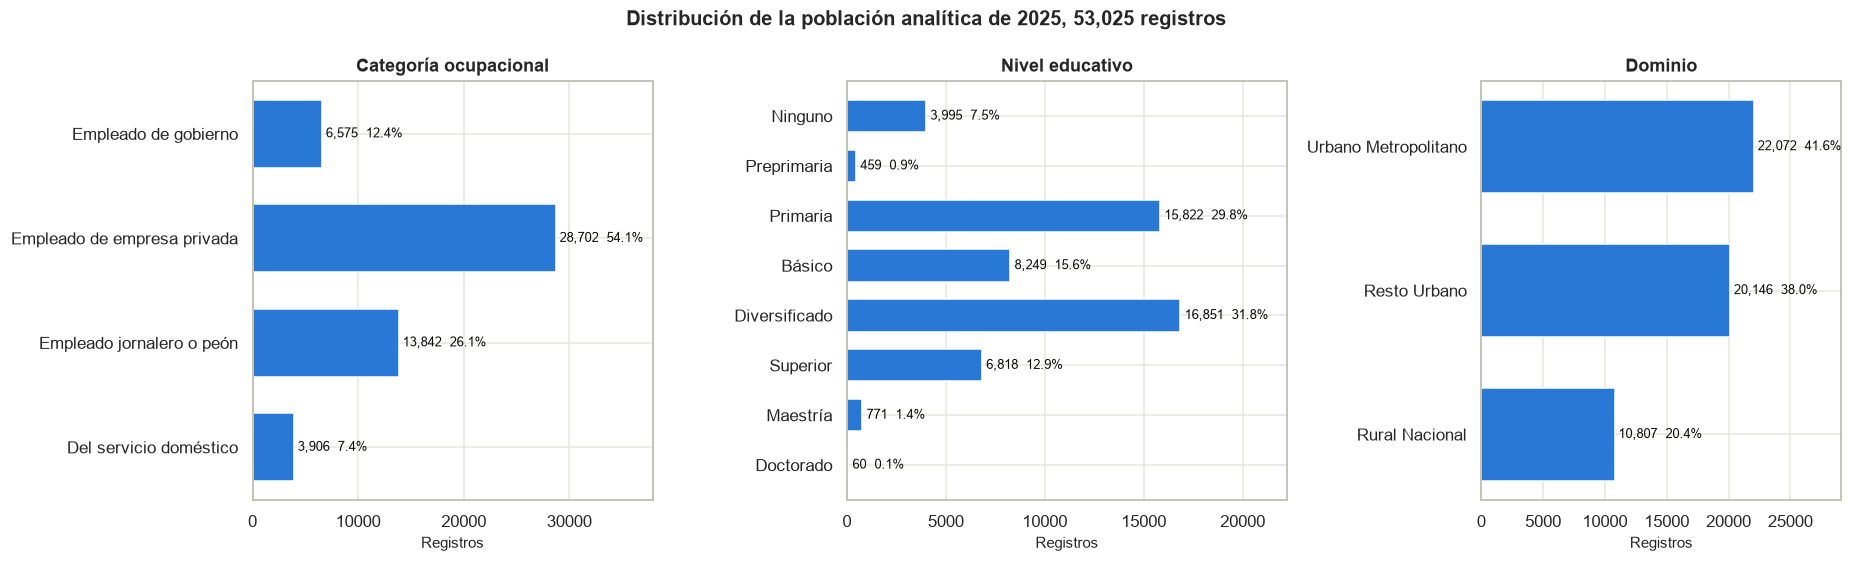

In [25]:
figura, ejes = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={"width_ratios": [1, 1.1, 0.9]})
for eje, tabla, titulo in [
    (ejes[0], dist_ocupacional, "Categoría ocupacional"),
    (ejes[1], dist_educativo, "Nivel educativo"),
    (ejes[2], dist_dominio, "Dominio"),
]:
    eje.barh(tabla.index, tabla["registros"], color=COLOR_PRINCIPAL, height=0.65)
    eje.invert_yaxis()
    eje.set_title(titulo)
    eje.set_xlabel("Registros")
    limite = tabla["registros"].max() * 1.32
    eje.set_xlim(0, limite)
    for posicion, (valor, pct) in enumerate(zip(tabla["registros"], tabla["porcentaje"])):
        eje.text(valor + limite * 0.01, posicion, f"{int(valor):,}  {pct:.1f}%", va="center", fontsize=8.5, color="#0b0b0b")
figura.suptitle(f"Distribución de la población analítica de 2025, {TOTAL_2025:,} registros", fontsize=13, fontweight="bold")
plt.tight_layout()
guardar_figura("Distribución de los registros de 2025 por categoría ocupacional, nivel educativo y dominio")
plt.show()

La población asalariada está dominada por el empleo privado, con 54.1% de los registros, seguido por jornaleros o peones con 26.1%, empleados de gobierno con 12.4% y servicio doméstico con 7.4%. En educación predominan el diversificado con 31.8% y la primaria con 29.8%, seguidos por básico con 15.6% y superior con 12.9%; el 7.5% no tiene ningún nivel aprobado, y maestría y doctorado son muy escasos, con 771 y 60 registros. Por dominio, el 41.6% de los registros es urbano metropolitano, el 38.0% resto urbano y el 20.4% rural nacional. Varias categorías tienen pocos registros, en particular preprimaria, maestría y doctorado, lo que conviene recordar al comparar estadísticos entre grupos y al codificarlas en los modelos.

### 2.3 – Forma de la distribución del salario

Se calculan la asimetría, la curtosis y la distancia entre media y mediana sobre el conjunto completo. La distribución se muestra en dos paneles construidos con conteos de Spark: en escala original, con intervalos de 500 quetzales hasta el percentil 99 y el resto agrupado en el último intervalo, y en escala logarítmica de base 10 sobre el eje horizontal. La escala logarítmica es solo un recurso visual y el objetivo del modelado sigue en quetzales.

In [26]:
forma = analitica_2025.agg(
    F.mean("salario_mensual").alias("media"),
    F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
    F.expr("percentile(salario_mensual, 0.99)").alias("p99"),
    F.skewness("salario_mensual").alias("asimetria"),
    F.kurtosis("salario_mensual").alias("curtosis_exceso"),
).first().asDict()
forma["media_menos_mediana"] = forma["media"] - forma["mediana"]
forma["razon_media_mediana"] = forma["media"] / forma["mediana"]
forma["registros_sobre_media_pct"] = 100 * analitica_2025.filter(F.col("salario_mensual") > forma["media"]).count() / TOTAL_2025
pd.Series(forma).round(3).to_frame("valor")

,valor
media,3421.684
mediana,3000.000
p99,15000.000
asimetria,5.997
curtosis_exceso,103.519
media_menos_mediana,421.684
razon_media_mediana,1.141
registros_sobre_media_pct,43.723


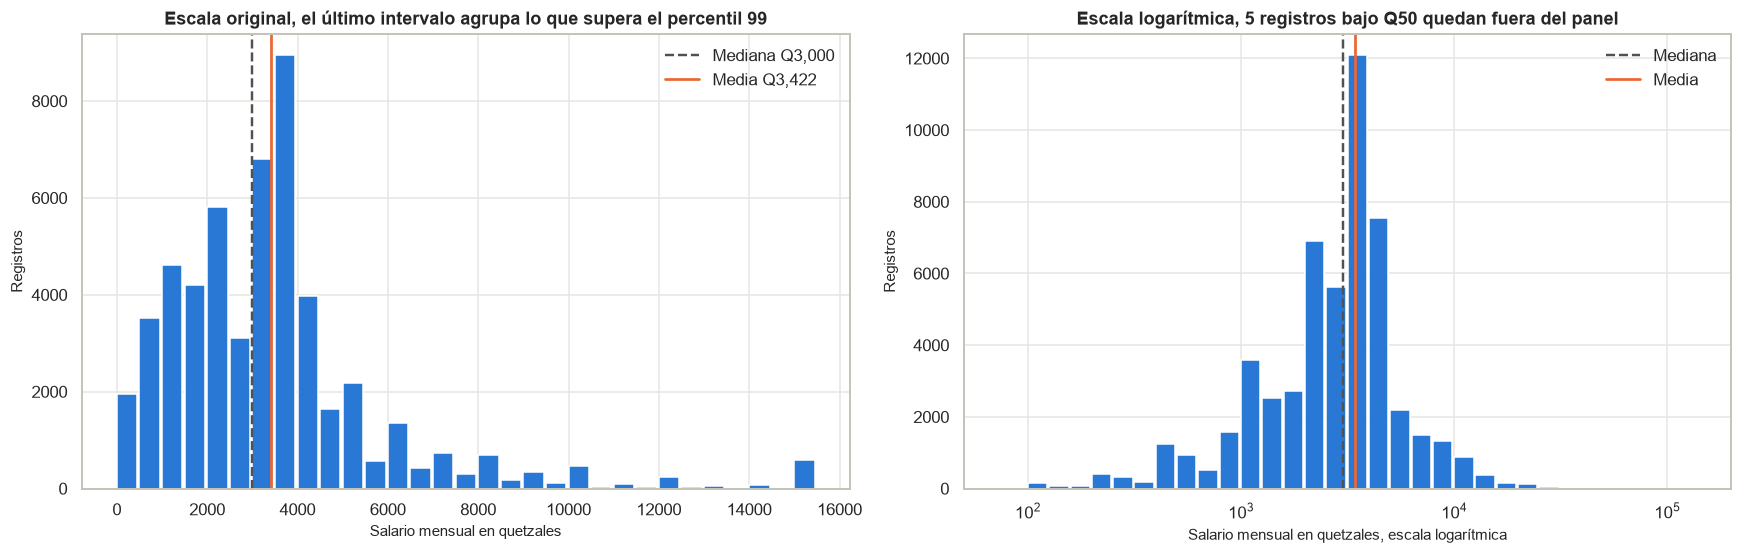

In [27]:
ANCHO = 500
tope = math.ceil(forma["p99"] / ANCHO) * ANCHO

# conteos por intervalo calculados en Spark sobre todos los registros
hist_original = (
    analitica_2025.withColumn("intervalo", F.least(F.floor(F.col("salario_mensual") / ANCHO) * ANCHO, F.lit(tope)))
    .groupBy("intervalo").count().orderBy("intervalo").toPandas()
)
hist_log = (
    analitica_2025.withColumn("intervalo", F.floor(F.log10("salario_mensual") / 0.1) * 0.1)
    .groupBy("intervalo").count().orderBy("intervalo").toPandas()
)

figura, ejes = plt.subplots(1, 2, figsize=(16, 5.2))

ejes[0].bar(hist_original["intervalo"], hist_original["count"], width=ANCHO * 0.9, align="edge", color=COLOR_PRINCIPAL)
ejes[0].axvline(forma["mediana"], color=COLOR_REFERENCIA, linestyle="--", linewidth=1.6, label=f"Mediana Q{forma['mediana']:,.0f}")
ejes[0].axvline(forma["media"], color=COLOR_CONTRASTE, linewidth=1.8, label=f"Media Q{forma['media']:,.0f}")
ejes[0].set_title("Escala original, el último intervalo agrupa lo que supera el percentil 99")
ejes[0].set_xlabel("Salario mensual en quetzales")
ejes[0].set_ylabel("Registros")
ejes[0].legend(frameon=False)

ejes[1].bar(10 ** hist_log["intervalo"], hist_log["count"], width=(10 ** (hist_log["intervalo"] + 0.1) - 10 ** hist_log["intervalo"]) * 0.9,
            align="edge", color=COLOR_PRINCIPAL)
ejes[1].set_xscale("log")
LIMITE_INFERIOR = 50
fuera_del_panel = int(analitica_2025.filter(F.col("salario_mensual") < LIMITE_INFERIOR).count())
ejes[1].set_xlim(LIMITE_INFERIOR, 2e5)
ejes[1].axvline(forma["mediana"], color=COLOR_REFERENCIA, linestyle="--", linewidth=1.6, label="Mediana")
ejes[1].axvline(forma["media"], color=COLOR_CONTRASTE, linewidth=1.8, label="Media")
ejes[1].set_title(f"Escala logarítmica, {fuera_del_panel} registros bajo Q{LIMITE_INFERIOR} quedan fuera del panel")
ejes[1].set_xlabel("Salario mensual en quetzales, escala logarítmica")
ejes[1].set_ylabel("Registros")
ejes[1].legend(frameon=False)

plt.tight_layout()
guardar_figura("Distribución del salario mensual de 2025 en escala original y logarítmica")
plt.show()

La distribución del salario es claramente asimétrica a la derecha. La asimetría vale 6.0 y la curtosis en exceso 103.5, muy lejos de los valores cercanos a cero de una distribución normal. La mayor parte de los registros se concentra entre Q1,000 y Q5,000, pero la cola derecha se extiende hasta Q99,000, cuando el percentil 99 es Q15,000. En escala logarítmica la forma se vuelve mucho más simétrica, lo que confirma que la asimetría es de tipo multiplicativo. Se observa además un fuerte agrupamiento en montos redondos como Q3,000 y Q4,000, que refleja que los salarios se reportan de forma aproximada. El valor máximo de Q99,000 corresponde a una misma persona reportada con ese monto en tres cortes consecutivos, por lo que parece una respuesta consistente y no un código especial; se conserva, como pide el enunciado.

### 2.4 – Salario mediano por nivel educativo y por categoría ocupacional

Para cada grupo se calculan el número de observaciones, la mediana y el rango intercuartílico sobre todos los registros. La figura muestra la mediana como punto y el intervalo entre los percentiles 25 y 75 como segmento, e indica el número de observaciones de cada grupo, porque una mediana basada en pocos registros es menos estable.

In [28]:
def salario_por_grupo(sdf, columna, orden):
    tabla = (
        sdf.groupBy(columna)
        .agg(F.count(F.lit(1)).alias("n"),
             F.expr("percentile(salario_mensual, array(0.25, 0.5, 0.75))").alias("p"),
             F.mean("salario_mensual").alias("media"))
        .toPandas().set_index(columna).reindex(orden)
    )
    tabla[["p25", "mediana", "p75"]] = pd.DataFrame(tabla.pop("p").tolist(), index=tabla.index)
    return tabla[["n", "p25", "mediana", "p75", "media"]]


salario_educativo = salario_por_grupo(analitica_2025, "nivel_educativo_etiqueta", ORDEN_EDUCATIVO)
salario_ocupacional = salario_por_grupo(analitica_2025, "categoria_ocupacional_etiqueta", ORDEN_OCUPACIONAL)
salario_dominio = salario_por_grupo(analitica_2025, "dominio_etiqueta", ORDEN_DOMINIO)
display(salario_educativo.round(1))
display(salario_ocupacional.round(1))
display(salario_dominio.round(1))

,n,p25,mediana,p75,media
nivel_educativo_etiqueta,,,,,
Ninguno,3995,800.0,1500.0,2400.0,1767.1
Preprimaria,459,1200.0,2160.0,3000.0,2241.9
Primaria,15822,1200.0,2200.0,3200.0,2308.0
Básico,8249,1600.0,2800.0,3600.0,2730.2
Diversificado,16851,2800.0,3600.0,4250.0,3796.4
Superior,6818,3600.0,5000.0,7500.0,5965.3
Maestría,771,6000.0,10000.0,15000.0,11409.3
Doctorado,60,6000.0,12000.0,21000.0,14452.3


,n,p25,mediana,p75,media
categoria_ocupacional_etiqueta,,,,,
Empleado de gobierno,6575,3750.0,5000.0,7380.0,5971.5
Empleado de empresa privada,28702,2800.0,3567.5,4000.0,3875.1
Empleado jornalero o peón,13842,1000.0,1800.0,2489.8,1878.6
Del servicio doméstico,3906,600.0,1000.0,1600.0,1265.7


,n,p25,mediana,p75,media
dominio_etiqueta,,,,,
Urbano Metropolitano,22072,2800.0,3700.0,4500.0,4190.9
Resto Urbano,20146,1600.0,2880.0,3800.0,3131.1
Rural Nacional,10807,1200.0,2000.0,3200.0,2392.4


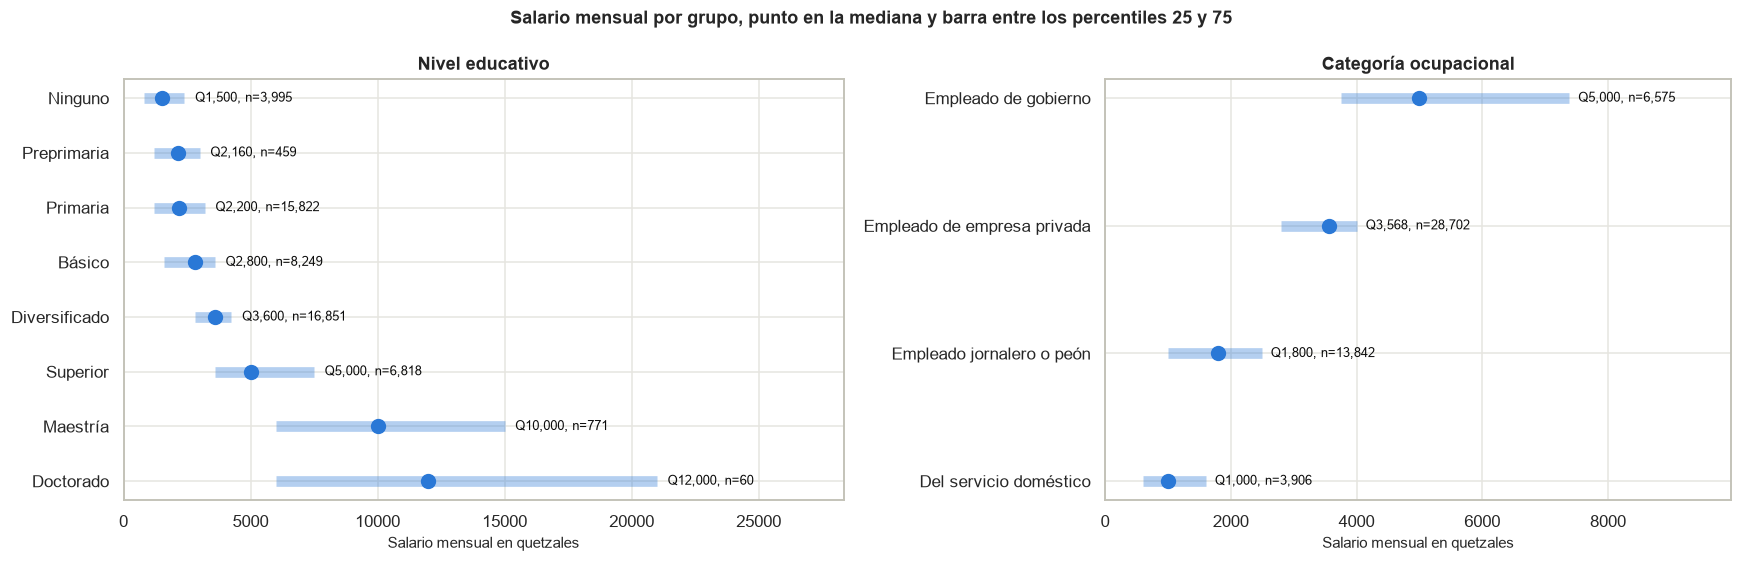

In [29]:
figura, ejes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.15, 1]})
for eje, tabla, titulo in [
    (ejes[0], salario_educativo, "Nivel educativo"),
    (ejes[1], salario_ocupacional, "Categoría ocupacional"),
]:
    posiciones = np.arange(len(tabla))
    eje.hlines(posiciones, tabla["p25"], tabla["p75"], color=COLOR_PRINCIPAL, alpha=0.35, linewidth=7)
    eje.plot(tabla["mediana"], posiciones, "o", color=COLOR_PRINCIPAL, markersize=9)
    desplazamiento = tabla["p75"].max() * 0.02
    for y, (mediana, p75, n) in enumerate(zip(tabla["mediana"], tabla["p75"], tabla["n"])):
        eje.text(p75 + desplazamiento, y, f"Q{mediana:,.0f}, n={int(n):,}", va="center", fontsize=8.5, color="#0b0b0b")
    eje.set_yticks(posiciones, tabla.index)
    eje.invert_yaxis()
    eje.set_xlim(0, tabla["p75"].max() * 1.35)
    eje.set_title(titulo)
    eje.set_xlabel("Salario mensual en quetzales")
figura.suptitle("Salario mensual por grupo, punto en la mediana y barra entre los percentiles 25 y 75", fontsize=12, fontweight="bold")
plt.tight_layout()
guardar_figura("Salario mediano y rango intercuartílico por nivel educativo y por categoría ocupacional")
plt.show()

El salario mediano crece de forma monotónica con el nivel educativo: pasa de Q1,500 sin ningún nivel a Q2,200 con primaria, Q2,800 con básico, Q3,600 con diversificado, Q5,000 con educación superior, Q10,000 con maestría y Q12,000 con doctorado. El rango intercuartílico también se ensancha con la educación, de modo que los niveles más altos no solo ganan más sino que presentan mayor dispersión. Entre categorías ocupacionales las diferencias son igualmente marcadas: los empleados de gobierno tienen la mediana más alta con Q5,000, seguidos por los de empresa privada con Q3,568, los jornaleros con Q1,800 y el servicio doméstico con Q1,000. Por dominio la mediana baja de Q3,700 en el área urbana metropolitana a Q2,880 en el resto urbano y Q2,000 en el área rural. Las medianas de maestría y doctorado se basan en pocos registros, en particular 60 para doctorado, y deben leerse con cautela.

### 2.5 – Tamaño de la muestra y salario mediano por trimestre

Se compara la población analítica de cada corte de 2025 con la del corte de prueba de 2026. El tamaño y la mediana se presentan en paneles separados porque tienen escalas distintas.

,n,mediana,media,originales,retencion_pct
periodo_archivo,,,,,
2025T1,13419,3000.0,3315.6,51588,26.0
2025T2,13492,3000.0,3364.6,51167,26.4
2025T3,13450,3200.0,3469.1,51583,26.1
2025T4,12664,3200.0,3544.6,49338,25.7
2026T1,13258,3200.0,3565.8,49843,26.6


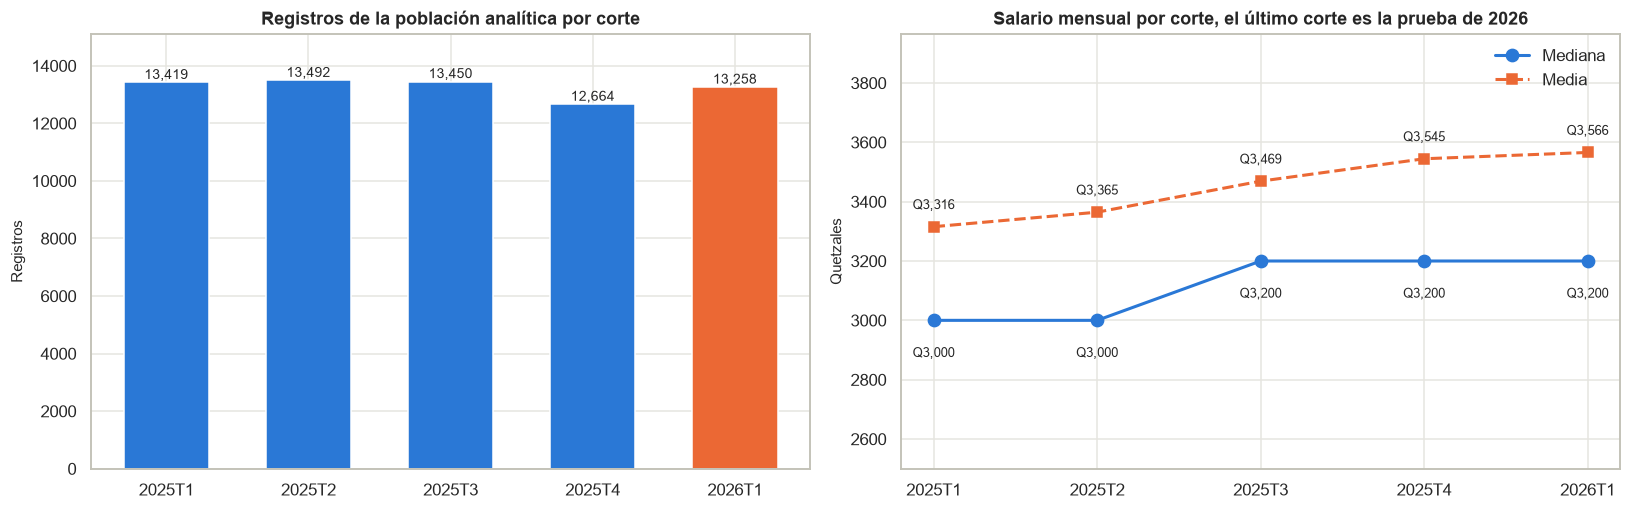

In [30]:
evolucion = (
    analitica_2025.unionByName(analitica_2026)
    .groupBy("periodo_archivo")
    .agg(F.count(F.lit(1)).alias("n"),
         F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
         F.mean("salario_mensual").alias("media"))
    .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo")
)
evolucion["originales"] = por_archivo.loc[evolucion.index, "antes_de_filtros"].astype(int)
evolucion["retencion_pct"] = (100 * evolucion["n"] / evolucion["originales"]).round(2)
display(evolucion.round(1))

figura, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
colores = [COLOR_PRINCIPAL] * 4 + [COLOR_CONTRASTE]
ejes[0].bar(evolucion.index, evolucion["n"], color=colores, width=0.6)
for x, valor in enumerate(evolucion["n"]):
    ejes[0].text(x, valor + 120, f"{valor:,}", ha="center", fontsize=9)
ejes[0].set_ylim(0, evolucion["n"].max() * 1.12)
ejes[0].set_title("Registros de la población analítica por corte")
ejes[0].set_ylabel("Registros")

ejes[1].plot(evolucion.index, evolucion["mediana"], "o-", color=COLOR_PRINCIPAL, linewidth=2, markersize=8, label="Mediana")
ejes[1].plot(evolucion.index, evolucion["media"], "s--", color=COLOR_CONTRASTE, linewidth=2, markersize=7, label="Media")
for x, (mediana, media) in enumerate(zip(evolucion["mediana"], evolucion["media"])):
    ejes[1].text(x, mediana - 90, f"Q{mediana:,.0f}", ha="center", va="top", fontsize=8.5)
    ejes[1].text(x, media + 50, f"Q{media:,.0f}", ha="center", va="bottom", fontsize=8.5)
ejes[1].set_ylim(evolucion["mediana"].min() - 500, evolucion["media"].max() + 400)
ejes[1].set_title("Salario mensual por corte, el último corte es la prueba de 2026")
ejes[1].set_ylabel("Quetzales")
ejes[1].legend(frameon=False)
plt.tight_layout()
guardar_figura("Tamaño de la población analítica y salario mediano y medio por corte")
plt.show()

### 2.6 – Respuestas del ejercicio 2

Cómo se distribuyen los registros entre categorías ocupacionales, niveles educativos y dominios. La muestra analítica está concentrada en el empleo privado, que reúne más de la mitad de los registros, y en los niveles educativos intermedios, diversificado y primaria, que juntos suman el 61.6%. Cuatro de cada cinco registros son urbanos, con predominio del área metropolitana, y uno de cada cinco es rural. Los grupos con menos registros son servicio doméstico, preprimaria, maestría y doctorado.

Si el salario presenta una distribución simétrica o asimétrica. Es fuertemente asimétrico a la derecha, con asimetría de 6.0, curtosis en exceso de 103.5 y una cola larga de salarios altos poco frecuentes. El percentil 95 es Q8,000 y el percentil 99 es Q15,000, mientras que el máximo llega a Q99,000.

Qué diferencia existe entre su media y su mediana. La media es Q3,421.68 y la mediana Q3,000, de modo que la media supera a la mediana en Q421.68, un 14.1%. Solo el 43.7% de los registros gana más que la media. La diferencia se debe a que los pocos salarios muy altos elevan el promedio sin afectar a la mediana, que es por ello el mejor resumen del salario típico. Para el modelado esto implica que una pérdida cuadrática, como la de la regresión lineal y el RMSE, dará un peso desproporcionado a esos casos extremos.

Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales. Crece con cada nivel educativo, desde Q1,500 sin educación hasta Q5,000 con educación superior y Q12,000 con doctorado, y difiere de forma marcada entre categorías, desde Q1,000 en servicio doméstico hasta Q5,000 en el empleo público. Ambas variables separan el salario mucho más que las variables numéricas, como se confirmará en el ejercicio 3.

Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres. El tamaño es estable, entre 12,664 y 13,492 registros por corte, con una retención cercana al 26% en todos los archivos; el corte IV de 2025 es el más pequeño porque su archivo original también lo es. El salario mediano sube de Q3,000 en los dos primeros trimestres de 2025 a Q3,200 desde el tercero y se mantiene en Q3,200 en el corte de prueba de 2026. La media crece de forma continua, de Q3,315.6 a Q3,565.8, lo que sugiere un aumento gradual de los salarios nominales. Esta tendencia es relevante para la evaluación final, ya que los modelos se entrenarán con 2025 y se probarán en un período con salarios algo mayores.

## Ejercicio 3 – Correlación de Pearson entre salario, edad, antigüedad y horas

Este ejercicio mide la asociación lineal entre las cuatro variables numéricas de la población analítica de 2025. Las variables se combinan en una sola columna vectorial con VectorAssembler y la matriz se obtiene con Correlation.corr de pyspark.ml.stat sobre todos los registros elegibles. La matriz se presenta con sus etiquetas y como mapa de calor. Como complemento se calcula la correlación de Spearman, que trabaja sobre rangos y es menos sensible a la fuerte asimetría del salario, lo que ayuda a distinguir si una asociación débil de Pearson se debe a la forma de la distribución o a una relación realmente débil.

In [31]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

VARIABLES_CORRELACION = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
ETIQUETAS_CORRELACION = ["Salario", "Edad", "Antigüedad", "Horas"]

vector_correlacion = VectorAssembler(inputCols=VARIABLES_CORRELACION, outputCol="variables").transform(
    analitica_2025.select(*VARIABLES_CORRELACION)
)
matriz_pearson = pd.DataFrame(
    Correlation.corr(vector_correlacion, "variables", "pearson").first()[0].toArray(),
    index=ETIQUETAS_CORRELACION, columns=ETIQUETAS_CORRELACION,
)
matriz_spearman = pd.DataFrame(
    Correlation.corr(vector_correlacion, "variables", "spearman").first()[0].toArray(),
    index=ETIQUETAS_CORRELACION, columns=ETIQUETAS_CORRELACION,
)
print("Correlación de Pearson, registros utilizados:", vector_correlacion.count())
display(matriz_pearson.round(4))
print("Correlación de Spearman, complemento")
display(matriz_spearman.round(4))

Correlación de Pearson, registros utilizados: 53025


,Salario,Edad,Antigüedad,Horas
Salario,1.0000,0.1472,0.1796,0.0757
Edad,0.1472,1.0000,0.4867,-0.1054
Antigüedad,0.1796,0.4867,1.0000,-0.0623
Horas,0.0757,-0.1054,-0.0623,1.0000


Correlación de Spearman, complemento


,Salario,Edad,Antigüedad,Horas
Salario,1.0000,0.1526,0.2610,0.1431
Edad,0.1526,1.0000,0.4189,-0.1200
Antigüedad,0.2610,0.4189,1.0000,-0.0482
Horas,0.1431,-0.1200,-0.0482,1.0000


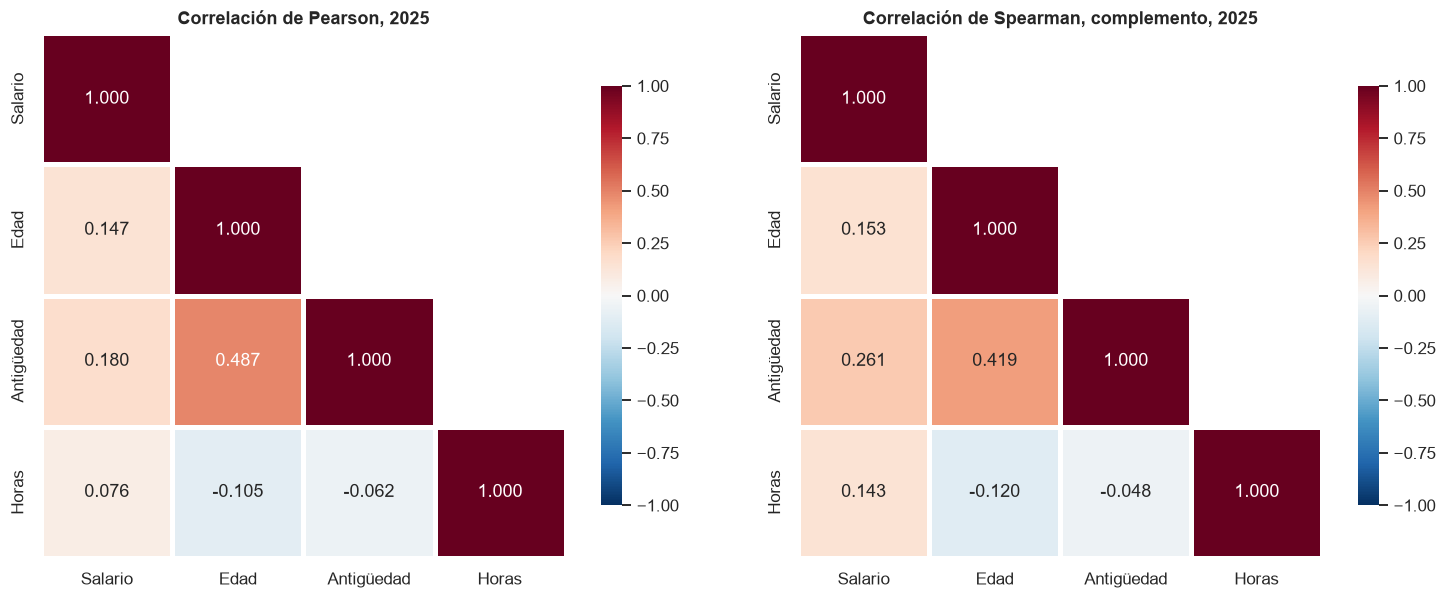

In [32]:
figura, ejes = plt.subplots(1, 2, figsize=(14, 5.4))
for eje, matriz, titulo in [(ejes[0], matriz_pearson, "Pearson"), (ejes[1], matriz_spearman, "Spearman, complemento")]:
    mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)
    sns.heatmap(matriz, mask=mascara, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                square=True, linewidths=2, linecolor="white", cbar_kws={"shrink": 0.8}, ax=eje)
    eje.grid(False)
    eje.set_title(f"Correlación de {titulo}, 2025")
plt.tight_layout()
guardar_figura("Mapa de calor de la correlación de Pearson y de Spearman entre salario, edad, antigüedad y horas")
plt.show()

Registros de la muestra de visualizacion: 5000


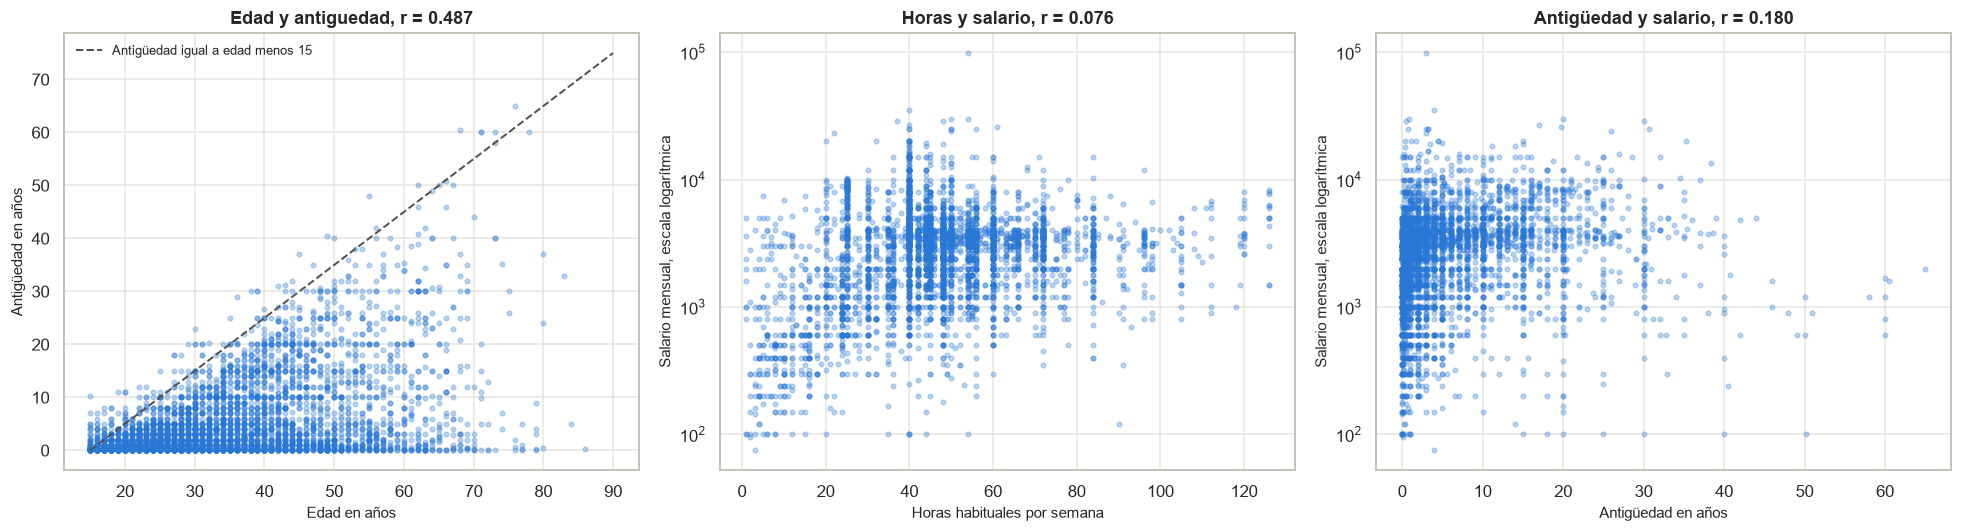

In [33]:
# muestra acotada unicamente para visualizar las nubes de puntos
muestra_relaciones = (
    analitica_2025.select(*VARIABLES_CORRELACION)
    .sample(withReplacement=False, fraction=0.12, seed=SEMILLA).limit(5000).toPandas()
)
print("Registros de la muestra de visualizacion:", len(muestra_relaciones))

figura, ejes = plt.subplots(1, 3, figsize=(18, 5))
ejes[0].scatter(muestra_relaciones["edad"], muestra_relaciones["antiguedad"], s=9, alpha=0.3, color=COLOR_PRINCIPAL)
limite_edad = np.array([15, 90])
ejes[0].plot(limite_edad, limite_edad - 15, color=COLOR_REFERENCIA, linestyle="--", linewidth=1.3, label="Antigüedad igual a edad menos 15")
ejes[0].set_title(f"Edad y antiguedad, r = {matriz_pearson.loc['Edad', 'Antigüedad']:.3f}")
ejes[0].set_xlabel("Edad en años")
ejes[0].set_ylabel("Antigüedad en años")
ejes[0].legend(frameon=False, fontsize=8.5)

for eje, variable, nombre in [(ejes[1], "horas_semanales", "Horas"), (ejes[2], "antiguedad", "Antigüedad")]:
    eje.scatter(muestra_relaciones[variable], muestra_relaciones["salario_mensual"], s=9, alpha=0.3, color=COLOR_PRINCIPAL)
    eje.set_yscale("log")
    eje.set_title(f"{nombre} y salario, r = {matriz_pearson.loc[nombre, 'Salario']:.3f}")
    eje.set_xlabel("Horas habituales por semana" if variable == "horas_semanales" else "Antigüedad en años")
    eje.set_ylabel("Salario mensual, escala logarítmica")
plt.tight_layout()
guardar_figura("Relación entre edad y antigüedad y entre horas, antigüedad y salario, muestra de 5,000 registros")
plt.show()

### 3.1 – Respuestas del ejercicio 3

Qué variables presentan mayor asociación lineal con el salario. Ninguna presenta una asociación fuerte. La antigüedad es la más asociada, con r igual a 0.180, seguida por la edad con 0.147 y las horas habituales con apenas 0.076. Con 53,025 registros estos coeficientes son estadísticamente distintos de cero, pero en términos prácticos cada variable por sí sola explica menos del 3.3% de la variación del salario, ya que el cuadrado de 0.180 es 0.032. La correlación de Spearman, que no depende de la forma de la distribución, es algo mayor, 0.261 para antigüedad, 0.153 para edad y 0.143 para horas, lo que indica que parte de la debilidad de Pearson se debe a la asimetría y a los valores extremos del salario, pero que aun en rangos las relaciones siguen siendo débiles. El caso de las horas es ilustrativo: más horas no se traducen en un salario mensual mayor de forma lineal, y, como se verá en el ejercicio 4, las jornadas más largas no se acompañan de un salario mensual mayor. Esto anticipa que las variables categóricas, nivel educativo y categoría ocupacional, que en el ejercicio 2 separaban el salario con claridad, serán más informativas para predecirlo que las numéricas.

Si existe relación entre edad y antigüedad. Sí, es la asociación más fuerte de la matriz, con r igual a 0.487 y Spearman de 0.419, lo cual es esperable porque la antigüedad solo puede acumularse con los años. La relación no es más fuerte porque es asimétrica: la antigüedad nunca supera la edad menos los años previos al empleo, lo que se ve en el borde diagonal de la nube de puntos, pero una persona de 50 años puede tener cualquier antigüedad entre cero y ese límite si cambió de empleo. Por eso la nube tiene forma de triángulo y no de recta. En cambio, las horas se asocian muy poco y de forma negativa con la edad, r igual a -0.105, y con la antigüedad, r igual a -0.062. Las tres variables numéricas, por tanto, aportan información en buena medida distinta, sin una colinealidad que complique los modelos.

## Ejercicio 4 – Segmentación de perfiles de asalariados mediante KMeans

Este ejercicio busca perfiles de trabajadores asalariados según su edad, su antigüedad en el empleo y su jornada habitual, que son las dimensiones planteadas en la primera pregunta del laboratorio. Para decidir si conviene incluir el salario se comparan tres espacios de agrupamiento: sin salario, con el salario en quetzales y con el logaritmo del salario, que atenúa su asimetría. En los tres las variables se estandarizan con StandardScaler y se entrena KMeans con K igual a 2, 3, 4 y 5 y semilla fija. Cada combinación se evalúa con la inercia, que es la suma de distancias cuadradas dentro de los grupos, con el coeficiente de silueta calculado sobre todos los registros y con el tamaño del clúster más pequeño. Con esa evidencia se elige primero el espacio y luego el número de grupos, y cada perfil se describe en unidades originales junto con su salario y su composición por categoría ocupacional, nivel educativo y dominio.

### 4.1 – Espacios de agrupamiento y estandarización

KMeans usa distancia euclidiana, de modo que sin estandarizar la variable con mayor escala dominaría la formación de grupos. Cada espacio se ensambla con VectorAssembler y se estandariza restando la media y dividiendo entre la desviación estándar, con lo que las coordenadas de los centroides quedan expresadas en desviaciones estándar respecto del promedio.

In [34]:
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler

ESPACIOS = {
    "Sin salario": ["edad", "antiguedad", "horas_semanales"],
    "Con salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
    "Con logaritmo del salario": ["edad", "antiguedad", "horas_semanales", "log_salario"],
}
COLUMNA_ESPACIO = {nombre: f"z_{i}" for i, nombre in enumerate(ESPACIOS)}

base_segmentacion = analitica_2025.withColumn("log_salario", F.log("salario_mensual")).select(
    "periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "edad", "antiguedad", "horas_semanales", "salario_mensual", "log_salario",
    "nivel_educativo_etiqueta", "categoria_ocupacional_etiqueta", "dominio_etiqueta",
)

for nombre, variables in ESPACIOS.items():
    columna = COLUMNA_ESPACIO[nombre]
    escalado = Pipeline(stages=[
        VectorAssembler(inputCols=variables, outputCol=f"v{columna}"),
        StandardScaler(inputCol=f"v{columna}", outputCol=columna, withMean=True, withStd=True),
    ]).fit(base_segmentacion)
    base_segmentacion = escalado.transform(base_segmentacion).drop(f"v{columna}")
    print(f"{nombre:<27} {len(variables)} variables estandarizadas en la columna {columna}")

base_segmentacion = base_segmentacion.persist()
print("Registros utilizados:", base_segmentacion.count())

Sin salario                 3 variables estandarizadas en la columna z_0
Con salario                 4 variables estandarizadas en la columna z_1
Con logaritmo del salario   4 variables estandarizadas en la columna z_2
Registros utilizados: 53025


### 4.2 – Evaluación de los espacios y de los valores de K

Para cada espacio y cada K se entrena un modelo y se registran la inercia, la silueta sobre la totalidad de los registros, el porcentaje de registros del clúster más pequeño y la reducción relativa de la inercia respecto del K anterior. También se registra, para cada variable del espacio, la mayor distancia de un centroide al promedio, medida en desviaciones estándar, lo que indica si esa variable llega a diferenciar a algún grupo.

In [35]:
VALORES_K = [2, 3, 4, 5]
resultados_k, modelos_k = [], {}

for nombre, variables in ESPACIOS.items():
    columna = COLUMNA_ESPACIO[nombre]
    evaluador = ClusteringEvaluator(featuresCol=columna, predictionCol="cluster", metricName="silhouette",
                                    distanceMeasure="squaredEuclidean")
    for k in VALORES_K:
        modelo = KMeans(featuresCol=columna, predictionCol="cluster", k=k, seed=SEMILLA, maxIter=100).fit(base_segmentacion)
        modelos_k[(nombre, k)] = modelo
        tamanios = modelo.summary.clusterSizes
        centros_z = np.abs(np.array(modelo.clusterCenters())).max(axis=0)
        fila = {"espacio": nombre, "k": k, "inercia": modelo.summary.trainingCost,
                "silueta": evaluador.evaluate(modelo.transform(base_segmentacion)),
                "cluster_menor_pct": 100 * min(tamanios) / sum(tamanios)}
        fila.update({f"max_z_{v}": z for v, z in zip(variables, centros_z)})
        resultados_k.append(fila)

tabla_k = pd.DataFrame(resultados_k)
tabla_k["reduccion_inercia_pct"] = -100 * tabla_k.groupby("espacio")["inercia"].pct_change()
tabla_k["cumple_tamanio"] = tabla_k["cluster_menor_pct"] >= 5
columnas_z = [c for c in tabla_k.columns if c.startswith("max_z_")]
tabla_k[["espacio", "k", "inercia", "reduccion_inercia_pct", "silueta", "cluster_menor_pct", "cumple_tamanio"] + columnas_z].round(3)

,espacio,k,inercia,reduccion_inercia_pct,silueta,cluster_menor_pct,cumple_tamanio,max_z_edad,max_z_antiguedad,max_z_horas_semanales,max_z_salario_mensual,max_z_log_salario
0,Sin salario,2,106717.386,NaN,0.555,27.508,True,1.191,1.055,0.268,NaN,NaN
1,Sin salario,3,83607.967,21.655,0.472,19.057,True,1.256,1.278,1.442,NaN,NaN
2,Sin salario,4,64438.208,22.928,0.476,12.950,True,1.088,2.131,1.527,NaN,NaN
3,Sin salario,5,56848.449,11.778,0.491,4.932,False,1.714,3.118,1.568,NaN,NaN
4,Con salario,2,157345.558,NaN,0.515,27.027,True,1.151,1.087,0.226,0.481,NaN
5,Con salario,3,133003.157,15.471,0.337,16.741,True,1.061,1.717,0.725,0.873,NaN
6,Con salario,4,113307.789,14.808,0.402,4.911,False,1.267,1.194,1.415,3.033,NaN
7,Con salario,5,97947.005,13.557,0.384,3.953,False,1.088,2.157,1.217,3.330,NaN
8,Con logaritmo del salario,2,159174.065,NaN,0.471,28.153,True,1.165,1.042,0.214,NaN,0.242
9,Con logaritmo del salario,3,125145.262,21.378,0.475,17.709,True,1.171,1.493,1.072,NaN,1.443


La comparación de espacios responde si vale la pena incluir el salario en la segmentación, y la respuesta es que no. El espacio sin salario obtiene la mayor silueta en K igual a 2, con 0.555, y en K igual a 4, con 0.476. Al agregar el salario en quetzales la silueta cae en todos los valores de K, llega a 0.337 en K igual a 3, y en K igual a 4 y 5 aparece un clúster de menos del 5% de los registros cuyo centroide está a más de 3 desviaciones estándar del salario promedio: el algoritmo dedica un grupo a aislar los salarios extremos, lo cual es una consecuencia de la asimetría del salario y no un perfil de trabajador. El logaritmo del salario corrige ese problema y alcanza una silueta de 0.475 en K igual a 3, pero cae a 0.372 en K igual a 4 y no supera al espacio sin salario. Hay además una razón conceptual: el objetivo es describir perfiles por trayectoria y jornada y luego observar cómo se remunera cada uno, y si el salario entra en el agrupamiento, la comparación salarial entre grupos se vuelve circular. Por estas razones el salario se utiliza como descriptor de los perfiles y no como variable de agrupamiento.

### 4.3 – Criterio de selección y modelo elegido

El espacio elegido es el que no incluye el salario, por las razones expuestas en la interpretación anterior. Dentro de ese espacio el número de grupos se elige con un criterio de tres condiciones que se verifica en el código. Primero, ningún clúster puede reunir menos del 5% de los registros, porque un grupo tan pequeño no constituye un perfil útil. Segundo, cada una de las tres variables debe diferenciar a por lo menos un grupo, es decir que algún centroide debe alejarse del promedio en al menos una desviación estándar en esa variable, ya que la pregunta del laboratorio pide perfiles según edad, antigüedad y jornada y no solo según una de ellas. Tercero, entre los valores de K que cumplen ambas condiciones se elige el de mayor silueta, y el resultado se contrasta con el criterio de codo.

In [36]:
ESPACIO_ELEGIDO = "Sin salario"
UMBRAL_TAMANIO = 5
UMBRAL_DIFERENCIACION = 1.0

curva = tabla_k[tabla_k["espacio"] == ESPACIO_ELEGIDO].copy()
curva["diferencia_todas"] = (curva[[f"max_z_{v}" for v in ESPACIOS[ESPACIO_ELEGIDO]]] >= UMBRAL_DIFERENCIACION).all(axis=1)
curva["admisible"] = curva["cumple_tamanio"] & curva["diferencia_todas"]
display(curva[["k", "silueta", "reduccion_inercia_pct", "cluster_menor_pct", "cumple_tamanio", "diferencia_todas", "admisible"]].round(3))

K_ELEGIDO = int(curva[curva["admisible"]].sort_values("silueta", ascending=False).iloc[0]["k"])
COLUMNA_ELEGIDA = COLUMNA_ESPACIO[ESPACIO_ELEGIDO]
modelo_elegido = modelos_k[(ESPACIO_ELEGIDO, K_ELEGIDO)]
fila_elegida = curva.set_index("k").loc[K_ELEGIDO]

print("Espacio elegido:", ESPACIO_ELEGIDO, "con", ", ".join(ESPACIOS[ESPACIO_ELEGIDO]))
print("K elegido      :", K_ELEGIDO)
print(f"Silueta        : {fila_elegida['silueta']:.4f}")
print(f"Cluster menor  : {fila_elegida['cluster_menor_pct']:.2f}% de los registros")

,k,silueta,reduccion_inercia_pct,cluster_menor_pct,cumple_tamanio,diferencia_todas,admisible
0,2,0.555,NaN,27.508,True,False,False
1,3,0.472,21.655,19.057,True,True,True
2,4,0.476,22.928,12.950,True,True,True
3,5,0.491,11.778,4.932,False,True,False


Espacio elegido: Sin salario con edad, antiguedad, horas_semanales
K elegido      : 4
Silueta        : 0.4760
Cluster menor  : 12.95% de los registros


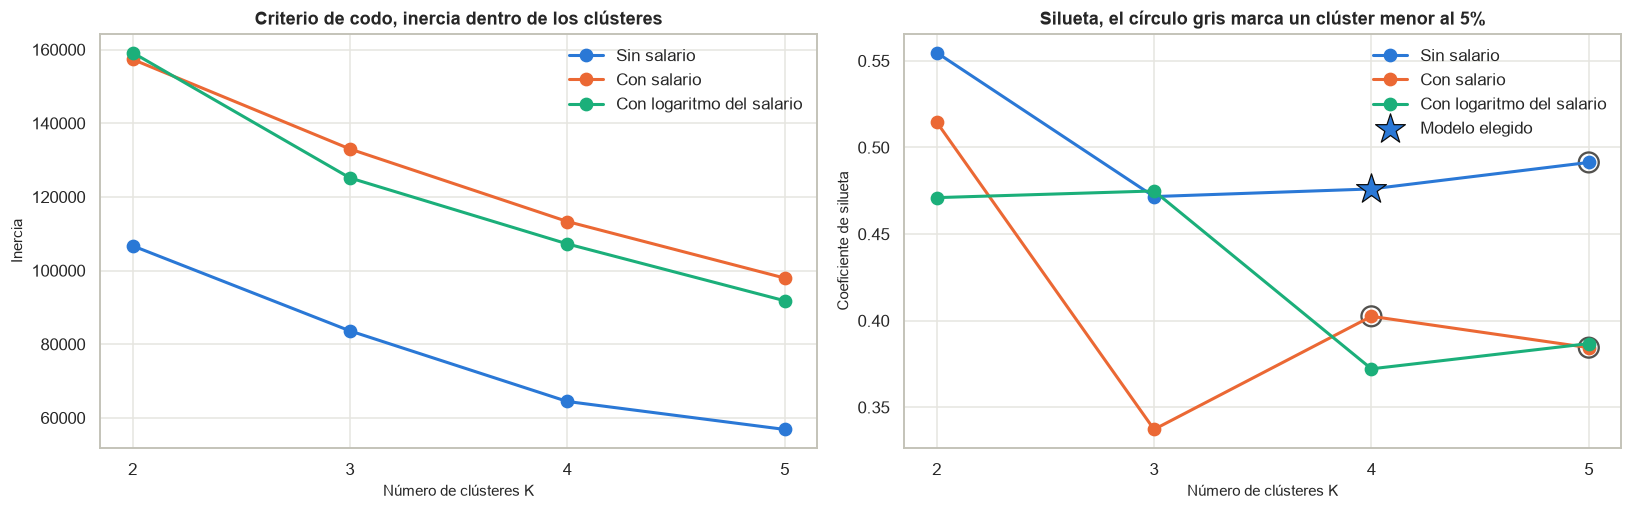

In [37]:
figura, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
for posicion, (nombre, grupo) in enumerate(tabla_k.groupby("espacio", sort=False)):
    color = PALETA_GRUPOS[posicion]
    ejes[0].plot(grupo["k"], grupo["inercia"], "o-", color=color, linewidth=2, markersize=8, label=nombre)
    ejes[1].plot(grupo["k"], grupo["silueta"], "o-", color=color, linewidth=2, markersize=8, label=nombre)
    descartados = grupo[~grupo["cumple_tamanio"]]
    ejes[1].scatter(descartados["k"], descartados["silueta"], s=170, facecolors="none", edgecolors=COLOR_REFERENCIA, linewidths=1.5)
ejes[1].scatter([K_ELEGIDO], [fila_elegida["silueta"]], marker="*", s=420, color=PALETA_GRUPOS[0],
                edgecolors="#0b0b0b", linewidths=0.8, zorder=5, label="Modelo elegido")
ejes[0].set_title("Criterio de codo, inercia dentro de los clústeres")
ejes[0].set_ylabel("Inercia")
ejes[1].set_title("Silueta, el círculo gris marca un clúster menor al 5%")
ejes[1].set_ylabel("Coeficiente de silueta")
for eje in ejes:
    eje.set_xlabel("Número de clústeres K")
    eje.set_xticks(VALORES_K)
    eje.legend(frameon=False)
plt.tight_layout()
guardar_figura("Criterio de codo y coeficiente de silueta por espacio de agrupamiento y valor de K")
plt.show()

El máximo de silueta se alcanza en K igual a 2, con 0.555, pero ese modelo no cumple la segunda condición: sus centroides se separan en edad y antigüedad, alrededor de una desviación estándar, y apenas 0.27 desviaciones estándar en horas. Es decir, K igual a 2 solo divide a los asalariados en jóvenes con poca antigüedad y mayores con más antigüedad, que es la misma relación ya medida en el ejercicio 3, y deja la jornada sin explicar. K igual a 5 se descarta porque uno de sus clústeres reúne solo el 4.93% de los registros. Entre K igual a 3 y K igual a 4, ambos admisibles, el criterio elige K igual a 4, con silueta de 0.476 frente a 0.472. El criterio de codo coincide: la inercia se reduce 21.7% al pasar de 2 a 3 grupos y 22.9% al pasar de 3 a 4, pero solo 11.8% al pasar de 4 a 5, de modo que la ganancia se reduce a la mitad después de K igual a 4. Una silueta cercana a 0.48 indica una estructura moderada: los perfiles describen regiones de un continuo más que grupos aislados, lo cual es habitual en variables laborales y debe tenerse en cuenta al interpretarlos.

### 4.4 – Perfiles del modelo seleccionado

Se asigna el clúster a cada registro y se describe cada grupo por su tamaño, por la distribución de edad, antigüedad y horas en unidades originales, y por su salario. Los clústeres se renumeran como perfiles por edad media ascendente, para que la numeración sea estable entre ejecuciones. El salario no participó en la formación de los grupos, por lo que su comparación entre perfiles muestra cómo se remunera cada tipo de trayectoria.

In [38]:
asignada = modelo_elegido.transform(base_segmentacion)

orden = (
    asignada.groupBy("cluster").agg(F.mean("edad").alias("e"))
    .toPandas().sort_values("e")["cluster"].tolist()
)
recodificar = F.create_map(*[x for i, c in enumerate(orden) for x in (F.lit(c), F.lit(i + 1))])
asignada = asignada.withColumn("perfil", F.element_at(recodificar, F.col("cluster"))).persist()
PERFILES = list(range(1, K_ELEGIDO + 1))

perfiles = (
    asignada.groupBy("perfil")
    .agg(F.count(F.lit(1)).alias("n"),
         F.mean("edad").alias("edad_media"),
         F.mean("antiguedad").alias("antiguedad_media"),
         F.expr("percentile(antiguedad, 0.5)").alias("antiguedad_mediana"),
         F.mean("horas_semanales").alias("horas_medias"),
         F.expr("percentile(horas_semanales, 0.5)").alias("horas_mediana"),
         F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
         F.mean("salario_mensual").alias("salario_medio"))
    .orderBy("perfil").toPandas().set_index("perfil")
)
perfiles.insert(1, "participacion_pct", 100 * perfiles["n"] / perfiles["n"].sum())
perfiles.round(1)

,n,participacion_pct,edad_media,antiguedad_media,antiguedad_mediana,horas_medias,horas_mediana,salario_mediano,salario_medio
perfil,,,,,,,,,
1,24488,46.2,25.8,2.4,1.2,40.9,44.0,3000.0,3074.7
2,8928,16.8,30.5,3.5,2.0,74.8,72.0,3000.0,3240.9
3,12742,24.0,48.5,4.1,3.0,39.5,42.0,3000.0,3536.7
4,6867,13.0,49.9,22.2,20.0,41.1,40.0,3800.0,4680.6


In [39]:
def composicion(columna, orden_categorias):
    """Porcentaje de cada categoria dentro de cada perfil."""
    tabla = asignada.groupBy("perfil", columna).count().toPandas().pivot(index="perfil", columns=columna, values="count")
    tabla = tabla.reindex(columns=[c for c in orden_categorias if c in tabla.columns]).fillna(0)
    return (100 * tabla.div(tabla.sum(axis=1), axis=0)).round(1)


comp_ocupacional = composicion("categoria_ocupacional_etiqueta", ORDEN_OCUPACIONAL)
comp_educativo = composicion("nivel_educativo_etiqueta", ORDEN_EDUCATIVO)
comp_dominio = composicion("dominio_etiqueta", ORDEN_DOMINIO)
print("Categoría ocupacional, porcentaje dentro de cada perfil")
display(comp_ocupacional)
print("Nivel educativo, porcentaje dentro de cada perfil")
display(comp_educativo)
print("Dominio, porcentaje dentro de cada perfil")
display(comp_dominio)

Categoría ocupacional, porcentaje dentro de cada perfil


categoria_ocupacional_etiqueta,Empleado de gobierno,Empleado de empresa privada,Empleado jornalero o peón,Del servicio doméstico
perfil,,,,
1,7.8,57.2,29.2,5.8
2,8.0,67.3,18.9,5.8
3,14.1,46.4,27.3,12.3
4,31.4,40.5,22.3,5.9


Nivel educativo, porcentaje dentro de cada perfil


nivel_educativo_etiqueta,Ninguno,Preprimaria,Primaria,Básico,Diversificado,Superior,Maestría,Doctorado
perfil,,,,,,,,
1,3.7,0.6,25.9,18.0,37.8,12.9,1.0,0.0
2,4.5,0.9,32.7,21.7,34.4,5.3,0.4,0.0
3,14.1,1.2,36.4,10.5,21.9,13.3,2.5,0.2
4,13.0,1.1,27.8,8.4,25.1,21.6,2.4,0.5


Dominio, porcentaje dentro de cada perfil


dominio_etiqueta,Urbano Metropolitano,Resto Urbano,Rural Nacional
perfil,,,
1,40.9,37.3,21.8
2,34.1,43.3,22.6
3,47.0,34.9,18.0
4,44.1,39.2,16.7


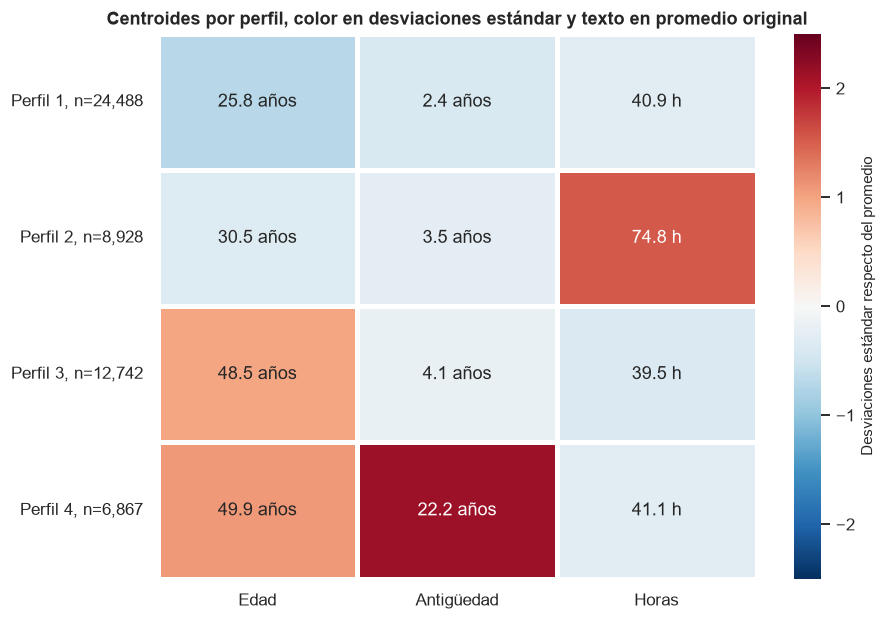

In [40]:
# centroides estandarizados como color y promedios en unidades originales como anotacion
nombres_espacio = ["Edad", "Antigüedad", "Horas"]
centros_z = pd.DataFrame(modelo_elegido.clusterCenters(), columns=nombres_espacio)
centros_z.index = [orden.index(c) + 1 for c in range(K_ELEGIDO)]
centros_z = centros_z.sort_index()
promedios = perfiles[["edad_media", "antiguedad_media", "horas_medias"]].to_numpy()
anotaciones = np.array([[f"{promedios[i, 0]:.1f} años", f"{promedios[i, 1]:.1f} años", f"{promedios[i, 2]:.1f} h"]
                        for i in range(K_ELEGIDO)])

figura, eje = plt.subplots(figsize=(8.5, 1.1 * K_ELEGIDO + 1.4))
sns.heatmap(centros_z, annot=anotaciones, fmt="", cmap="RdBu_r", center=0, vmin=-2.5, vmax=2.5,
            linewidths=2, linecolor="white", cbar_kws={"label": "Desviaciones estándar respecto del promedio"}, ax=eje)
eje.set_yticklabels([f"Perfil {p}, n={int(n):,}" for p, n in perfiles["n"].items()], rotation=0)
eje.set_xticklabels(nombres_espacio, rotation=0)
eje.set_title("Centroides por perfil, color en desviaciones estándar y texto en promedio original")
plt.tight_layout()
guardar_figura("Centroides estandarizados de los perfiles con sus promedios en unidades originales")
plt.show()

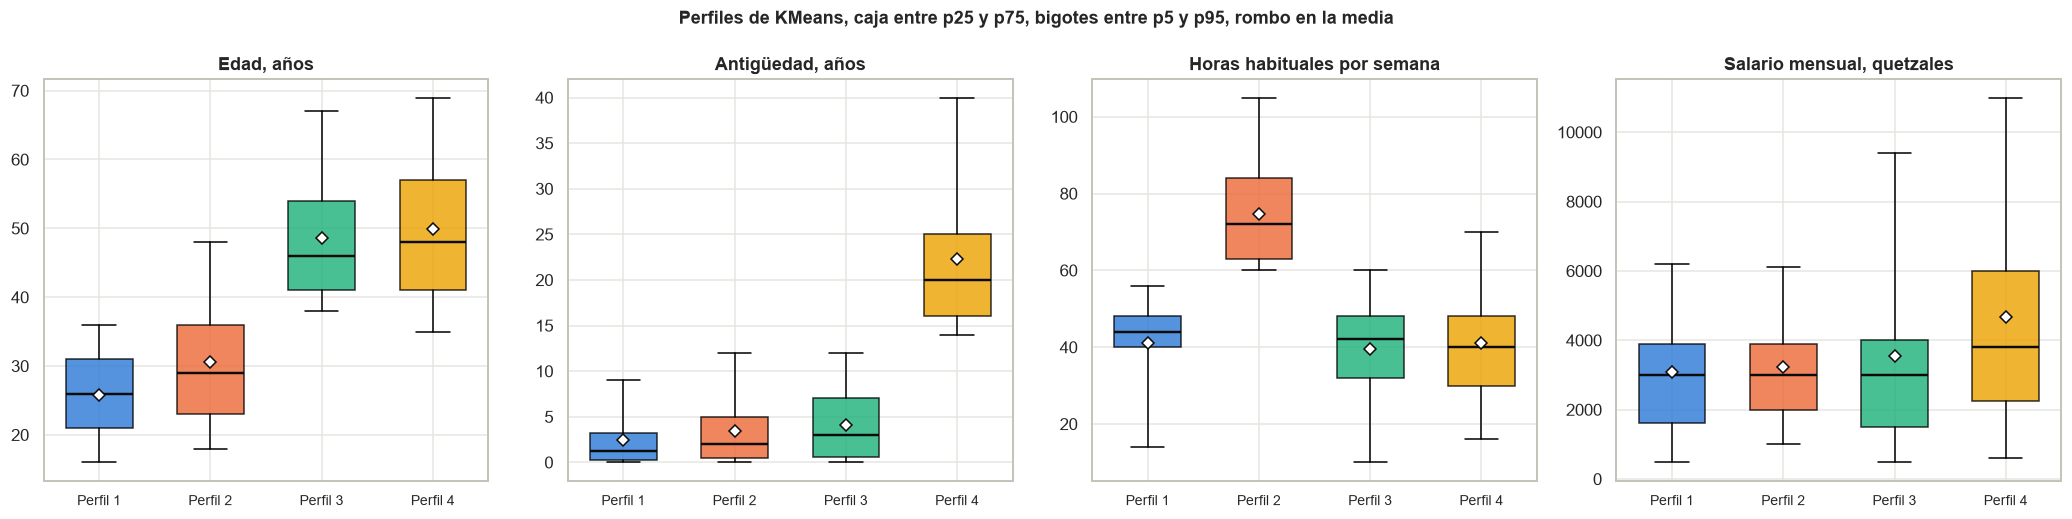

In [41]:
# estadisticos de caja calculados en Spark sobre todos los registros, bigotes en los percentiles 5 y 95
VARIABLES_CAJA = [("edad", "Edad, años"), ("antiguedad", "Antigüedad, años"),
                  ("horas_semanales", "Horas habituales por semana"), ("salario_mensual", "Salario mensual, quetzales")]
cuantiles = (
    asignada.groupBy("perfil")
    .agg(*[F.expr(f"percentile({v}, array(0.05, 0.25, 0.5, 0.75, 0.95))").alias(v) for v, _ in VARIABLES_CAJA],
         *[F.mean(v).alias(f"media_{v}") for v, _ in VARIABLES_CAJA])
    .orderBy("perfil").toPandas().set_index("perfil")
)

figura, ejes = plt.subplots(1, 4, figsize=(19, 4.8))
for eje, (variable, titulo) in zip(ejes, VARIABLES_CAJA):
    cajas = [{"label": f"Perfil {p}", "whislo": q[0], "q1": q[1], "med": q[2], "q3": q[3], "whishi": q[4],
              "mean": cuantiles.loc[p, f"media_{variable}"], "fliers": []}
             for p, q in cuantiles[variable].items()]
    partes = eje.bxp(cajas, showmeans=True, patch_artist=True, widths=0.6,
                     medianprops={"color": "#0b0b0b", "linewidth": 1.6},
                     meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "#0b0b0b", "markersize": 6})
    for caja, color in zip(partes["boxes"], PALETA_GRUPOS):
        caja.set_facecolor(color)
        caja.set_alpha(0.8)
    eje.set_title(titulo)
    eje.tick_params(axis="x", labelsize=9)
figura.suptitle("Perfiles de KMeans, caja entre p25 y p75, bigotes entre p5 y p95, rombo en la media", fontsize=12, fontweight="bold")
plt.tight_layout()
guardar_figura("Distribución de edad, antigüedad, horas y salario por perfil de KMeans sobre todos los registros")
plt.show()

### 4.5 – Descripción de los perfiles

El modelo elegido identifica cuatro perfiles de asalariados. La edad y la antigüedad los ordenan a lo largo de la trayectoria laboral, y la jornada aísla un grupo de horarios extendidos.

Perfil 1, jóvenes en inserción laboral con jornada estándar. Es el grupo más grande, con 24,488 registros, el 46.2%. Tienen en promedio 25.8 años, una antigüedad mediana de solo 1.2 años y una jornada mediana de 44 horas. Trabajan sobre todo en empresas privadas, 57.2%, y como jornaleros, 29.2%, y tienen el mayor peso de educación diversificada, 37.8%. Su salario mediano es de Q3,000 y su media de Q3,075, la más baja de los cuatro perfiles.

Perfil 2, trabajadores de jornada extendida. Reúne 8,928 registros, el 16.8%. Son también jóvenes, 30.5 años en promedio con 2 años de antigüedad mediana, pero su rasgo distintivo es la jornada: 74.8 horas semanales en promedio y 72 de mediana, con el 95% de sus integrantes en 60 horas o más. Es el perfil más concentrado en empresa privada, 67.3%, el de menor proporción de educación superior, 5.3%, y el de mayor presencia en el resto urbano, 43.3%. Su salario mediano es el mismo Q3,000 que el del perfil 1, lo que implica que casi 30 horas semanales adicionales no se traducen en un mayor salario mensual típico y que su remuneración por hora es sensiblemente menor.

Perfil 3, adultos con baja antigüedad. Reúne 12,742 registros, el 24.0%. Tienen 48.5 años en promedio pero solo 3 años de antigüedad mediana, lo que describe a personas de mediana edad que cambiaron de empleo o se reincorporaron recientemente. Su jornada mediana es de 42 horas, aunque con una cola de jornadas parciales. Concentran la mayor proporción de servicio doméstico, 12.3%, el doble que los demás, y un perfil educativo bajo, con 14.1% sin ningún nivel y 36.4% con primaria, aunque también incluyen un 13.3% con educación superior. Su salario mediano también es de Q3,000, con una media de Q3,537, y son el perfil más metropolitano, con 47.0%.

Perfil 4, trayectoria estable de larga permanencia. Es el grupo más pequeño, con 6,867 registros, el 13.0%. Tienen 49.9 años en promedio y 20 años de antigüedad mediana, con una jornada estándar de 40 horas. Es el único perfil con predominio relativo del empleo público, 31.4% frente al 12.4% general, y con la mayor proporción de educación superior o posgrado, 24.5%, aunque también un 13.0% sin ningún nivel. Es el único perfil cuyo salario se aparta del resto: mediana de Q3,800 y media de Q4,681, con el mayor rango intercuartílico.

La lectura conjunta es que la edad y la jornada, por sí solas, casi no distinguen el salario típico: tres de los cuatro perfiles comparten la mediana de Q3,000 a pesar de diferencias de más de 20 años de edad o de 30 horas semanales de jornada. Solo la permanencia prolongada en el mismo empleo, que va asociada a más empleo público y más educación superior, se acompaña de un salario claramente mayor. Esto es coherente con las correlaciones débiles del ejercicio 3 y sugiere que el nivel educativo y la categoría ocupacional serán los predictores con mayor peso en los modelos supervisados.

## Conclusiones

Los cinco archivos de la ENEIC pudieron armonizarse en una base analítica consistente, pero solo después de resolver tres problemas de origen: el corte IV de 2025 tiene una estructura de columnas distinta, el corte II de 2025 entrega los códigos como texto y la columna TRIMESTRE no identifica el trimestre calendario. La unión por nombre, la conversión a un esquema explícito y la identificación de cada registro por su archivo de procedencia evitan que esas diferencias contaminen el análisis.

La población analítica reúne 53,025 registros de asalariados en 2025, el 26.03% de la base original, y 13,258 en el corte de prueba de 2026. Los filtros que definen la población son los únicos que excluyen registros, ya que los faltantes de las variables de empleo son estructurales y dentro de los asalariados no queda ningún dato ausente. La clave de registro es única en cada corte, y el 78.7% de los registros corresponde a personas observadas en más de un trimestre, lo que confirma el carácter longitudinal de la base.

El salario mensual tiene una distribución fuertemente asimétrica, con una media de Q3,422 frente a una mediana de Q3,000 y una cola de valores altos poco frecuentes que se conserva en el análisis. Las diferencias salariales más claras aparecen entre niveles educativos, entre categorías ocupacionales y entre dominios, mientras que la edad, la antigüedad y las horas se asocian solo débilmente con el salario, con correlaciones de Pearson de 0.180 o menos.

La segmentación con KMeans sobre edad, antigüedad y jornada identificó cuatro perfiles: jóvenes en inserción laboral, trabajadores de jornada extendida, adultos con baja antigüedad y trabajadores de larga permanencia. Incluir el salario en el agrupamiento no mejoró la separación y, en quetzales, llevó a aislar los salarios extremos, por lo que se usó como descriptor. Tres de los cuatro perfiles comparten el mismo salario mediano, y solo la larga permanencia se asocia con un salario mayor.

En conjunto, estos resultados anticipan que predecir el salario individual será difícil con los seis predictores disponibles, que el nivel educativo y la categoría ocupacional aportarán la mayor parte de la capacidad predictiva, y que los salarios extremos y el leve aumento salarial observado en 2026 influirán en las métricas de evaluación. Los resultados describen a los registros analizados sin ponderar y no constituyen estimaciones oficiales de la población asalariada del país.